## **Análise Exploratória (atualizada) + Regressão Linear**

### **Dataset IPDM - 12 Medidas de Desenvolvimento**

**Objetivo:** Explorar as 12 variáveis do IPDM, entender suas distribuições, correlações e construir um modelo de regressão linear para explicar a variável **Economia** *(renda/atividade econômica)* a partir de outras variáveis como Consumo e Longevidade.

---

### **1. Configuração Inicial**

In [1]:
# Pacotes necessários
if (!require("pacman")) install.packages("pacman")
pacman::p_load(ggplot2, patchwork, corrplot, Hmisc, dplyr, tidyr, GGally)

# Aumentar tamanho padrão dos gráficos no Jupyter
options(repr.plot.width = 14, repr.plot.height = 10)

Carregando pacotes exigidos: pacman



### **2. Carregamento e Unificação dos Dados**

In [2]:
# Caminho dos arquivos (ajuste se necessário)
url <- "C:/Users/Ivan/Documents/Pasta-Documentos-PC-antigo/GITHUB-Meus-Repositorios/PesquisaTeoAprendiEstati_2026/data/processed/Datasets_IPDM/doze_medidas_desv/"

get_dataframe <- function(url, nm_arquivo) {
  read.csv(file = paste0(url, nm_arquivo))
}

# Carregar os 12 dataframes
df1 <- get_dataframe(url, '1_medida_longevi_1.csv')
df2 <- get_dataframe(url, '2_medida_longevi_2.csv')
df3 <- get_dataframe(url, '3_medida_longevi_3.csv')
df4 <- get_dataframe(url, '4_medida_longevi_4.csv')
df5 <- get_dataframe(url, '5_medida_escolari_1.csv')
df6 <- get_dataframe(url, '6_medida_escolari_2.csv')
df7 <- get_dataframe(url, '7_medida_escolari_3.csv')
df8 <- get_dataframe(url, '8_medida_escolari_4.csv')
df9 <- get_dataframe(url, '9_medida_economia_1.csv')
df10 <- get_dataframe(url, '10_medida_economia_2.csv')
df11 <- get_dataframe(url, '11_medida_consumo_1.csv')
df12 <- get_dataframe(url, '12_medida_consumo_2.csv')

# Unir todas as colunas 'valor' em um único dataframe (presumindo mesma ordem)
dados <- data.frame(
  longevidade1 = df1$valor,
  longevidade2 = df2$valor,
  longevidade3 = df3$valor,
  longevidade4 = df4$valor,
  escolaridade1 = df5$valor,
  escolaridade2 = df6$valor,
  escolaridade3 = df7$valor,
  escolaridade4 = df8$valor,
  economia1 = df9$valor,
  economia2 = df10$valor,
  consumo1 = df11$valor,
  consumo2 = df12$valor
)

# Verificar dados faltantes
cat("Totais de NA por variável:\n")
print(colSums(is.na(dados)))

# Dimensões
cat("\nDimensões do dataset unificado:", dim(dados))

Totais de NA por variável:
 longevidade1  longevidade2  longevidade3  longevidade4 escolaridade1 
            0             0             0             0             0 
escolaridade2 escolaridade3 escolaridade4     economia1     economia2 
            0             0             0             0             0 
     consumo1      consumo2 
            0             0 

Dimensões do dataset unificado: 54 12

### **3. Análise Exploratória (EDA) - Univariada**

Aqui descrevemos cada uma das 12 variáveis com resumos estatísticos e gráficos de distribuição.

In [3]:
# Resumo estatístico de todas as variáveis
summary(dados)

# Desvio padrão de cada uma
sds <- apply(dados, 2, sd, na.rm = TRUE)
print("Desvios padrão:")
print(round(sds, 2))

  longevidade1     longevidade2     longevidade3    longevidade4  
 Min.   : 7.806   Min.   : 8.543   Min.   :1.076   Min.   :13.94  
 1st Qu.:12.118   1st Qu.:12.315   1st Qu.:1.355   1st Qu.:17.19  
 Median :13.534   Median :13.878   Median :1.550   Median :19.40  
 Mean   :13.715   Mean   :13.901   Mean   :1.550   Mean   :19.91  
 3rd Qu.:15.311   3rd Qu.:15.288   3rd Qu.:1.689   3rd Qu.:22.07  
 Max.   :20.146   Max.   :21.388   Max.   :2.185   Max.   :33.00  
 escolaridade1   escolaridade2   escolaridade3   escolaridade4  
 Min.   :23.86   Min.   :39.72   Min.   :12.75   Min.   : 8.20  
 1st Qu.:30.49   1st Qu.:49.40   1st Qu.:23.11   1st Qu.:14.10  
 Median :39.21   Median :54.68   Median :27.13   Median :16.48  
 Mean   :38.98   Mean   :54.73   Mean   :26.69   Mean   :16.37  
 3rd Qu.:46.08   3rd Qu.:58.22   3rd Qu.:31.52   3rd Qu.:18.20  
 Max.   :58.11   Max.   :71.88   Max.   :37.29   Max.   :26.80  
   economia1        economia2         consumo1        consumo2     
 Min.   

[1] "Desvios padrão:"
 longevidade1  longevidade2  longevidade3  longevidade4 escolaridade1 
         2.76          2.67          0.25          3.85          9.07 
escolaridade2 escolaridade3 escolaridade4     economia1     economia2 
         7.30          5.81          3.52      59273.57        728.15 
     consumo1      consumo2 
         1.18         10.16 


### **3.1. Testes de Normalidade (Shapiro-Wilk)**

Reaproveitando os testes realizados anteriormente, temos os seguintes p-valores:

In [4]:
# Função Principal para Teste de Normalidade e Visualização gráfica
teste_normalidade_completo <- function(df_column, cor_grafico = "gray", cor_linha = "red") {
  
  dados_limpos <- na.omit(df_column)
  n_registros <- length(dados_limpos)
  
  # SE NÃO HOUVER DADOS CHEIOS, PARA AQUI PARA NÃO CRASHAR O R
  if (n_registros == 0) {
    cat("Aviso: A coluna está totalmente vazia.\n")
    return(NULL)
  }
  
  # --- BLOCO DOS GRÁFICOS (SEMPRE VAI EXECUTAR) ---
  options(repr.plot.width = 15, repr.plot.height = 5)
  par(mfrow = c(1, 3)) 
  
  # Gráfico 1: Histograma
  hist(dados_limpos, probability = TRUE, main = "Histograma", xlab = "Valores", 
       col = cor_grafico, cex.main = 2, cex.lab = 1.5, cex.axis = 1.5)
  lines(density(dados_limpos), col = cor_linha, lwd = 2)
  
  # Gráfico 2: Q-Q Plot
  qqnorm(dados_limpos, main = "Q-Q Plot", xlab = "Quantis Teóricos", ylab = "Quantis Amostrais",
         cex.main = 2, cex.lab = 1.5, cex.axis = 1.5)
  qqline(dados_limpos, col = cor_linha, lwd = 2)
  
  # Gráfico 3: Boxplot
  boxplot(dados_limpos, main = "Boxplot", col = cor_grafico, ylab = "Valores",
          cex.main = 2, cex.lab = 1.5, cex.axis = 1.5)
  
  # Restaura o layout padrão de gráficos do R
  par(mfrow = c(1, 1))
  
  # --- BLOCO DO TESTE ESTATÍSTICO (CONDICIONAL) ---
  if (n_registros >= 20 && n_registros <= 100) {
    result_shapiro <- shapiro.test(dados_limpos)
    p_valor <- result_shapiro$p.value
    
    cat("Resultados do teste de Shapiro-Wilk (n =", n_registros, "):\n")
    cat("p-value =", p_valor, "\n\n")
    
    if (p_valor > 0.05) {
      cat("=> Os dados seguem uma distribuição NORMAL (p > 0.05).\n")
      cat("Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).\n")
    } else {
      cat("=> Os dados NÃO seguem uma distribuição normal (p <= 0.05).\n")
      cat("Recomendação: Considere usar testes não paramétricos (ex: Wilcoxon, Kruskal-Wallis) ou transformar os dados.\n")
    }
  } else {
    cat("Aviso: Teste de Shapiro-Wilk não executado. Tamanho da amostra (", n_registros, ") fora do limite [20-100].\n", sep="")
    cat("Dica visual: Avalie a normalidade diretamente pelos 3 gráficos acima.\n")
  }
}



Teste Normalidade - df1$valor:


Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.8527675 

=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


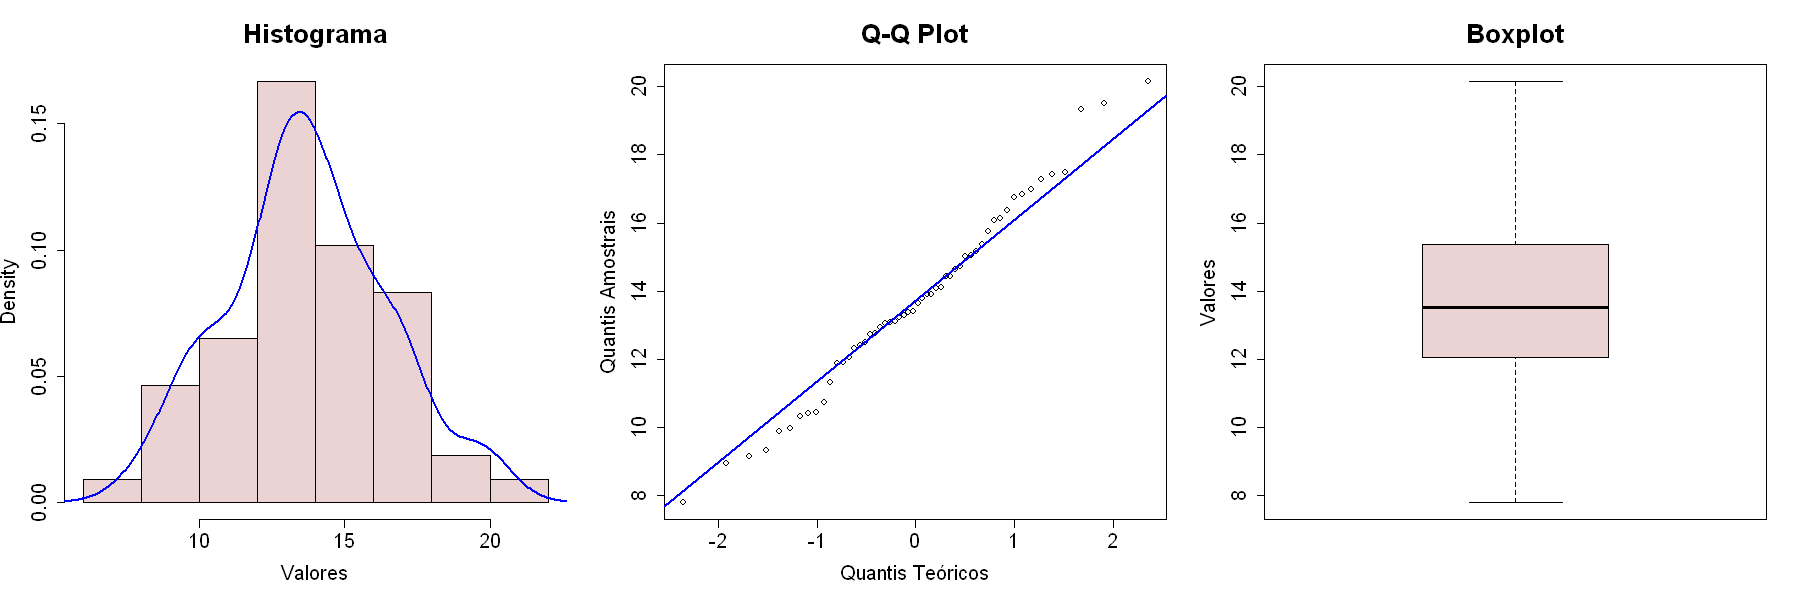

In [5]:
# Executando em: df1$valor
cat("===================================\n")
cat('Teste Normalidade - df1$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df1$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df2$valor:


Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.7708141 

=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


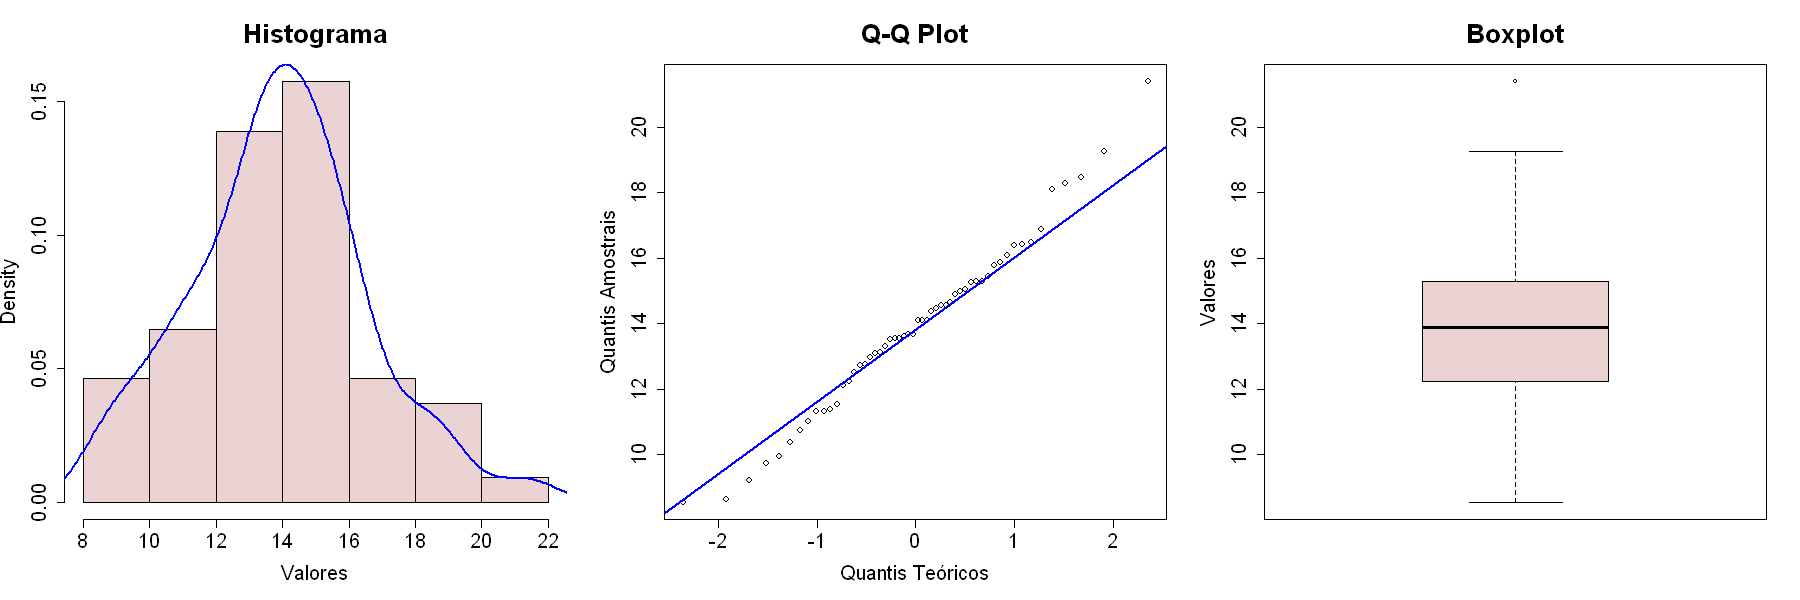

In [6]:
# Executando em: df2$valor
cat("===================================\n")
cat('Teste Normalidade - df2$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df2$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df3$valor:


Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.658588 

=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


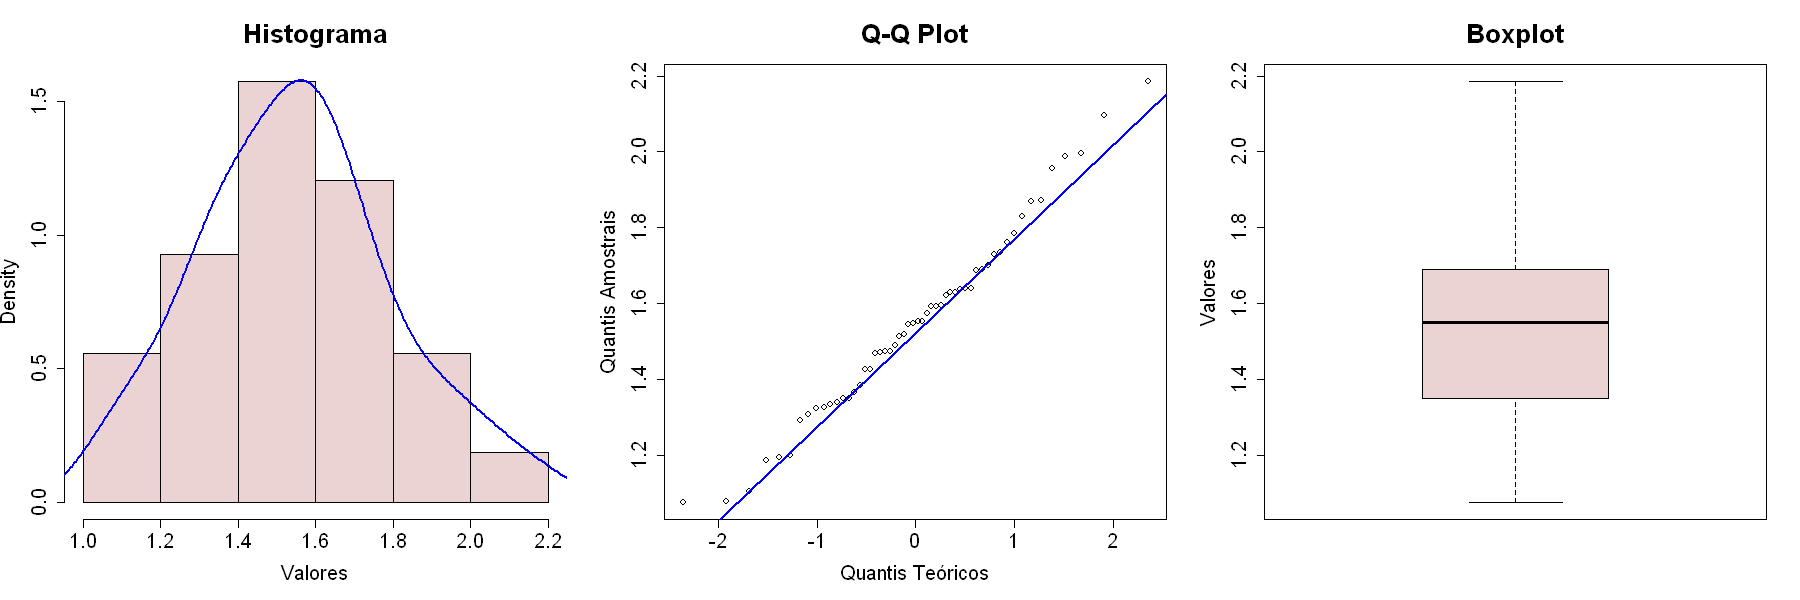

In [7]:
# Executando em: df3$valor
cat("===================================\n")
cat('Teste Normalidade - df3$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df3$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df4$valor:


Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.01319688 

=> Os dados NÃO seguem uma distribuição normal (p <= 0.05).
Recomendação: Considere usar testes não paramétricos (ex: Wilcoxon, Kruskal-Wallis) ou transformar os dados.


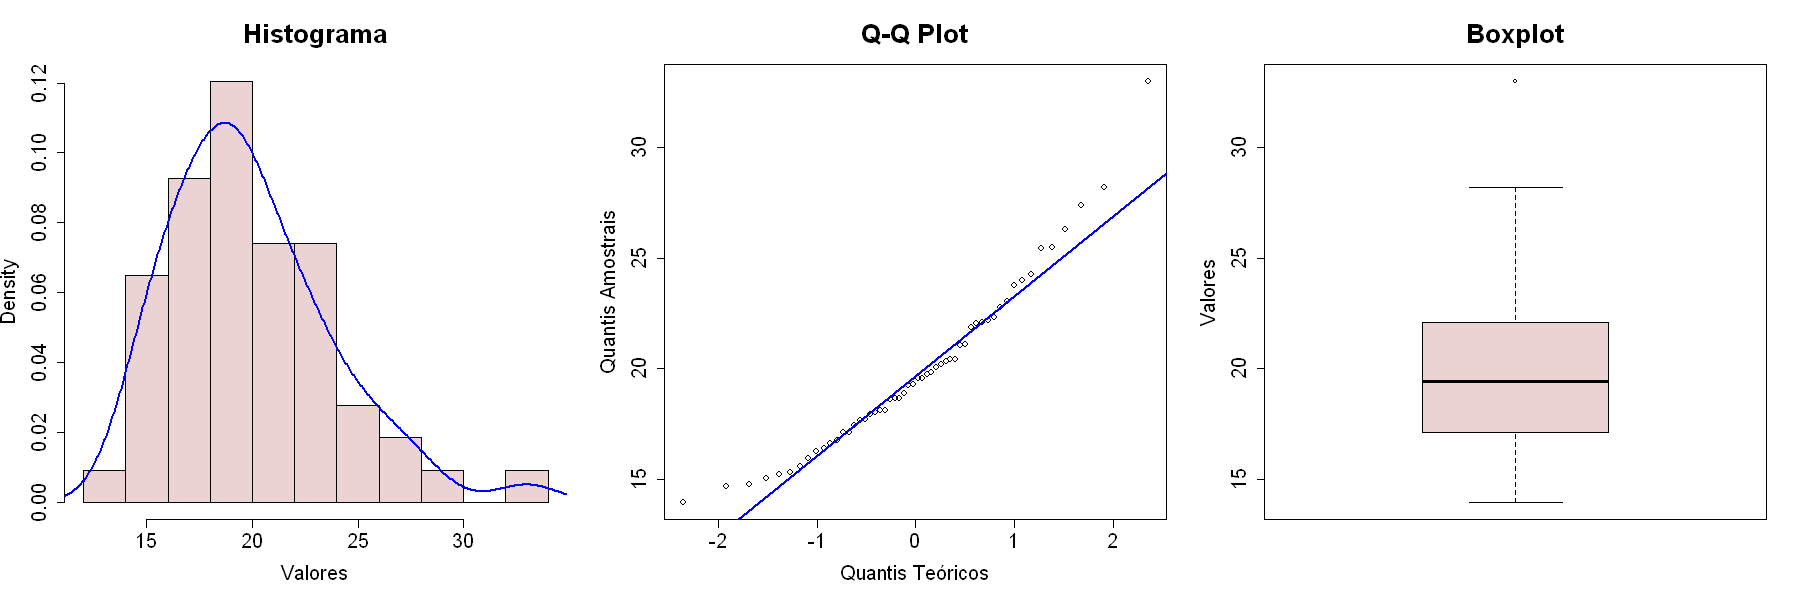

In [8]:
# Executando em: df4$valor
cat("===================================\n")
cat('Teste Normalidade - df4$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df4$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df5$valor:


Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.09854821 

=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


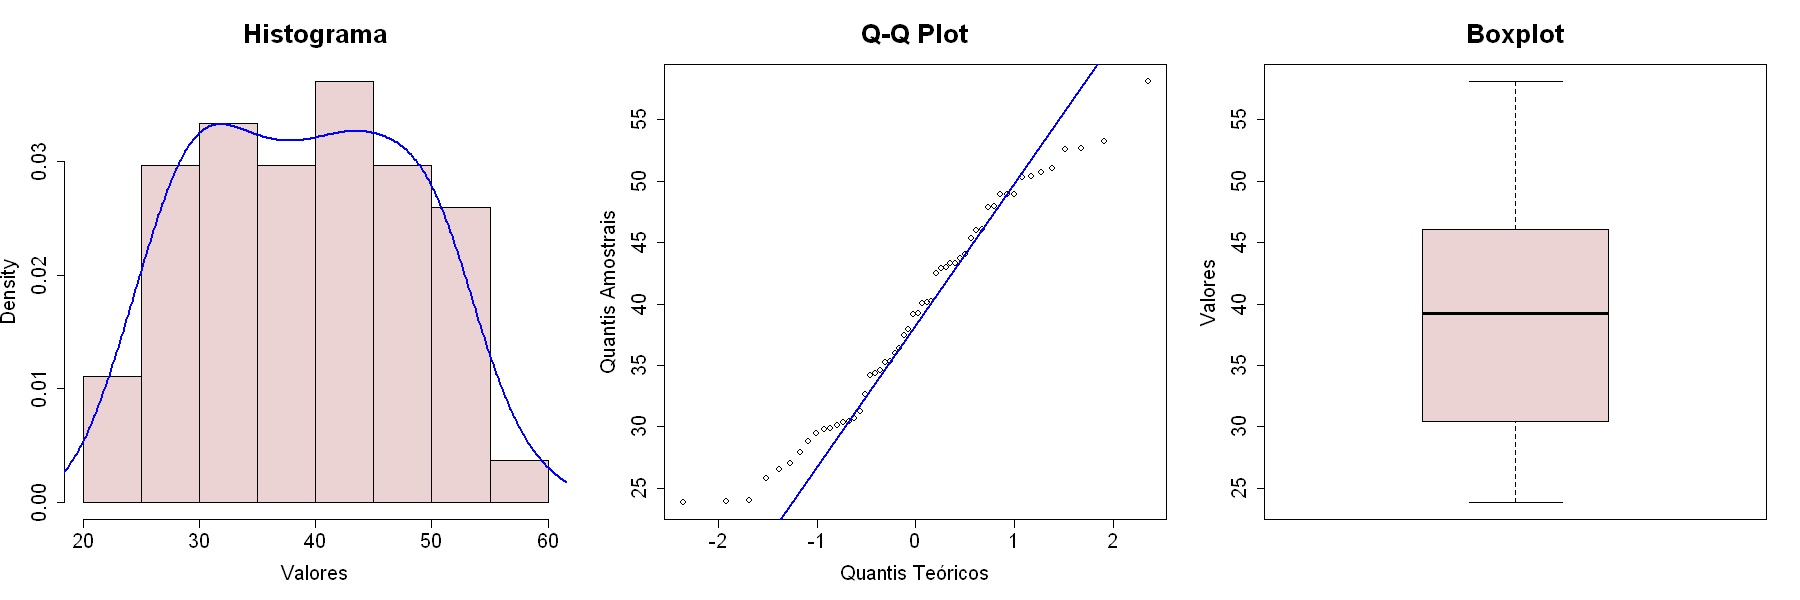

In [9]:
# Executando em: df5$valor
cat("===================================\n")
cat('Teste Normalidade - df5$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df5$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df6$valor:
Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.6911499 

=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


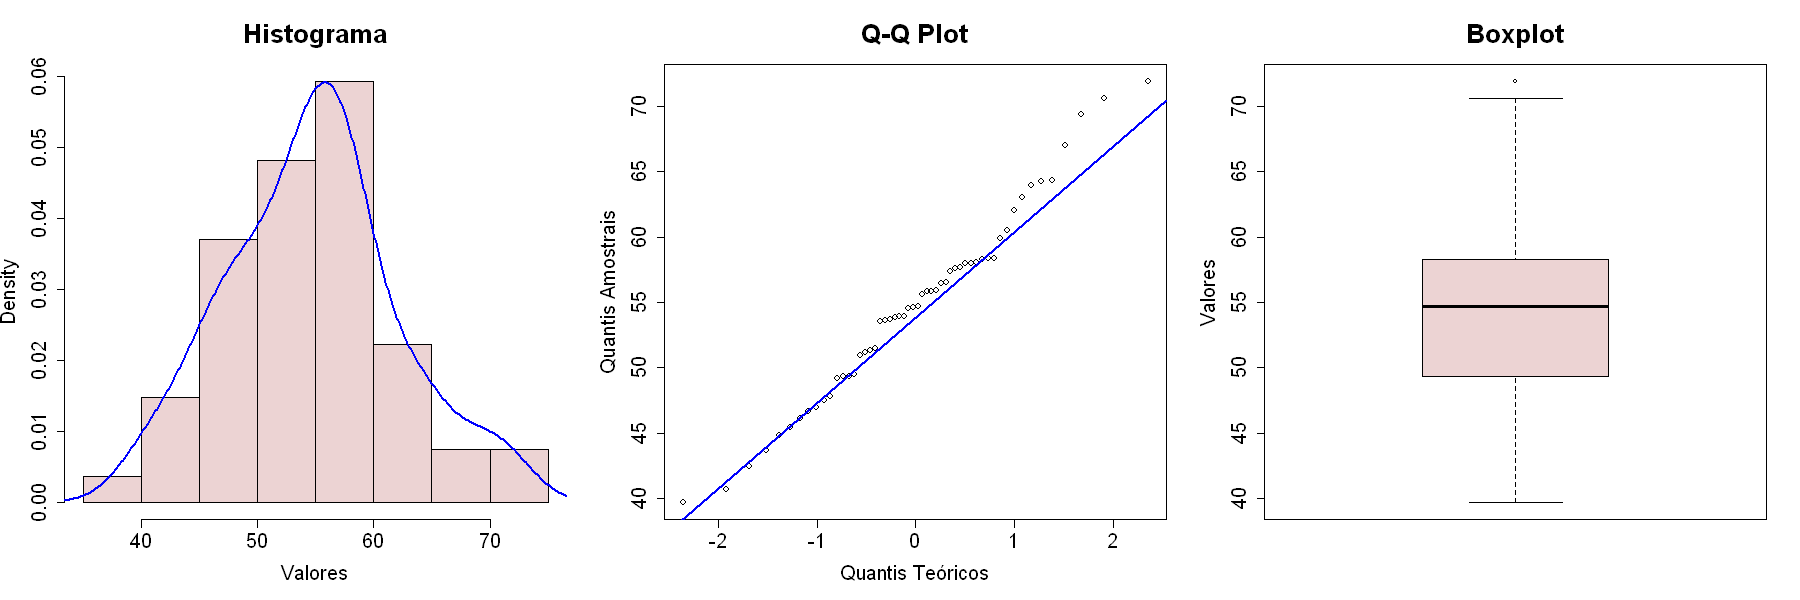

In [10]:
# Executando em: df6$valor
cat("===================================\n")
cat('Teste Normalidade - df6$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df6$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df7$valor:
Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.2575266 

=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


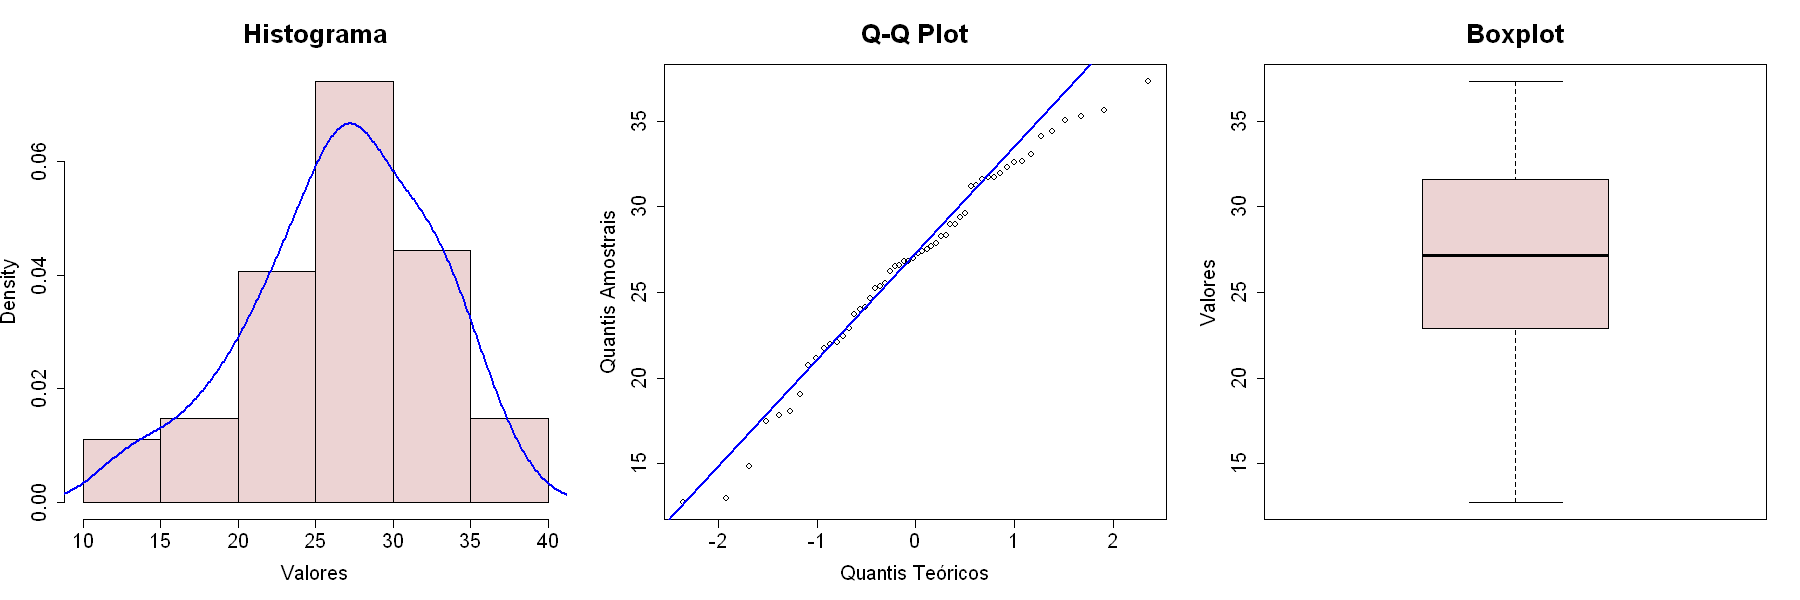

In [11]:
# Executando em: df7$valor
cat("===================================\n")
cat('Teste Normalidade - df7$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df7$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df8$valor:
Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.2304887 

=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


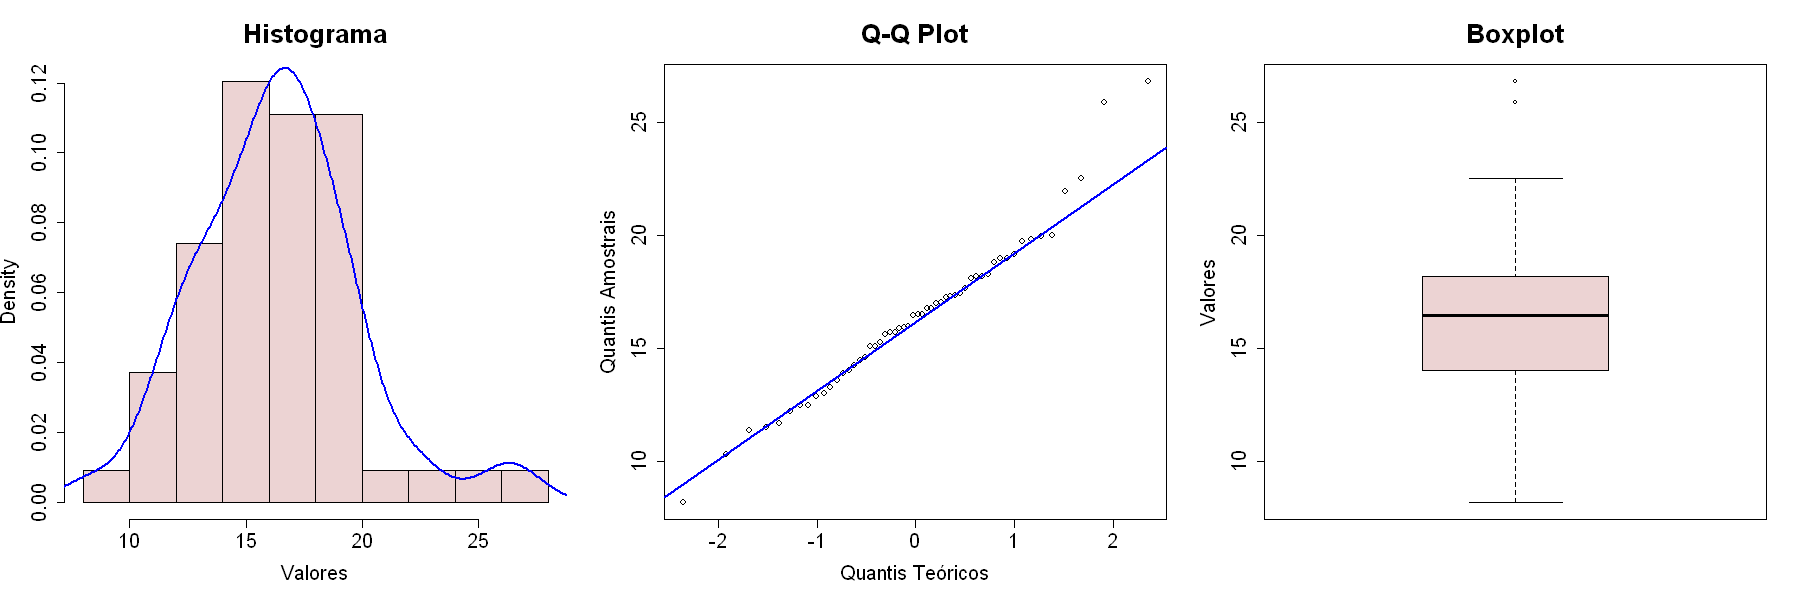

In [12]:
# Executando em: df8$valor
cat("===================================\n")
cat('Teste Normalidade - df8$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df8$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df9$valor:
Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 4.913598e-11 

=> Os dados NÃO seguem uma distribuição normal (p <= 0.05).
Recomendação: Considere usar testes não paramétricos (ex: Wilcoxon, Kruskal-Wallis) ou transformar os dados.


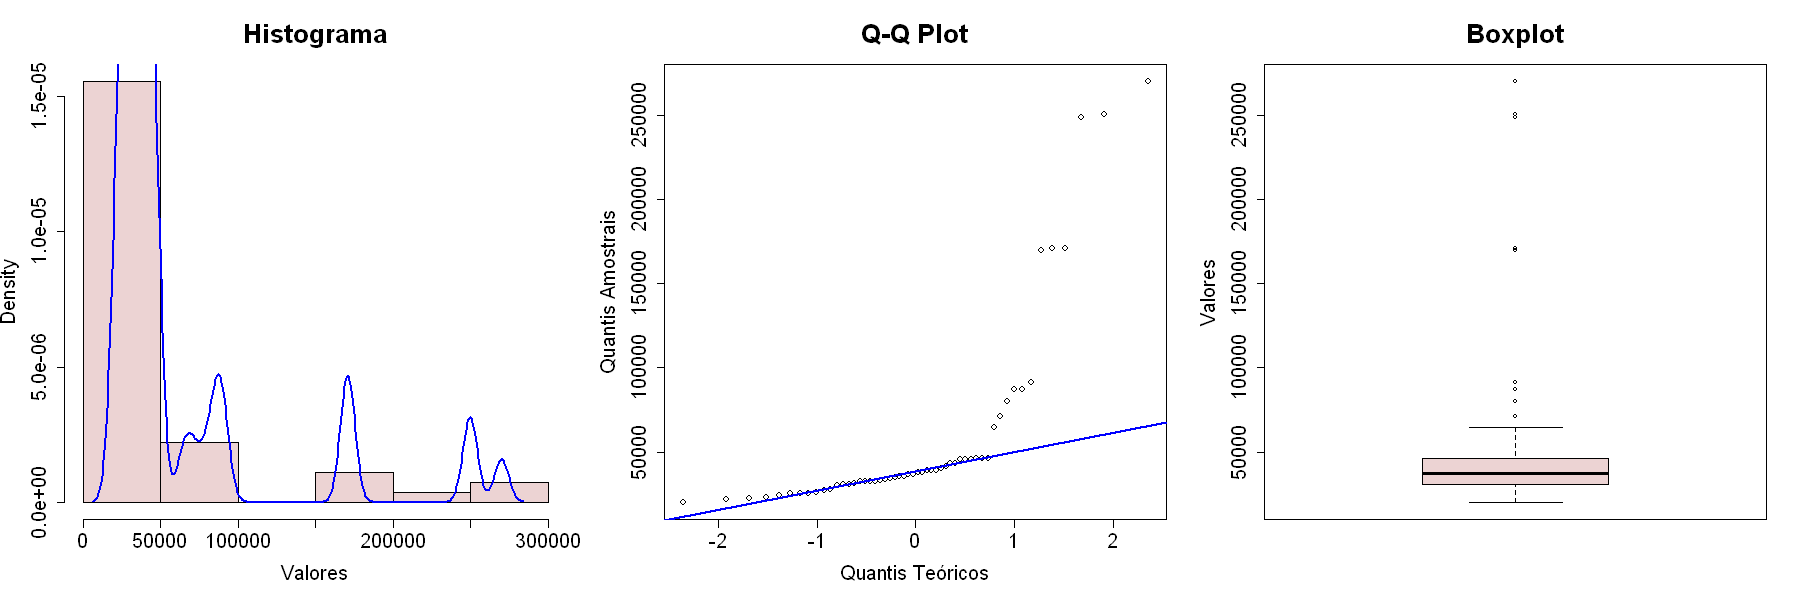

In [13]:
# Executando em: df9$valor
cat("===================================\n")
cat('Teste Normalidade - df9$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df9$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df10$valor:


Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 1.374303e-08 

=> Os dados NÃO seguem uma distribuição normal (p <= 0.05).
Recomendação: Considere usar testes não paramétricos (ex: Wilcoxon, Kruskal-Wallis) ou transformar os dados.


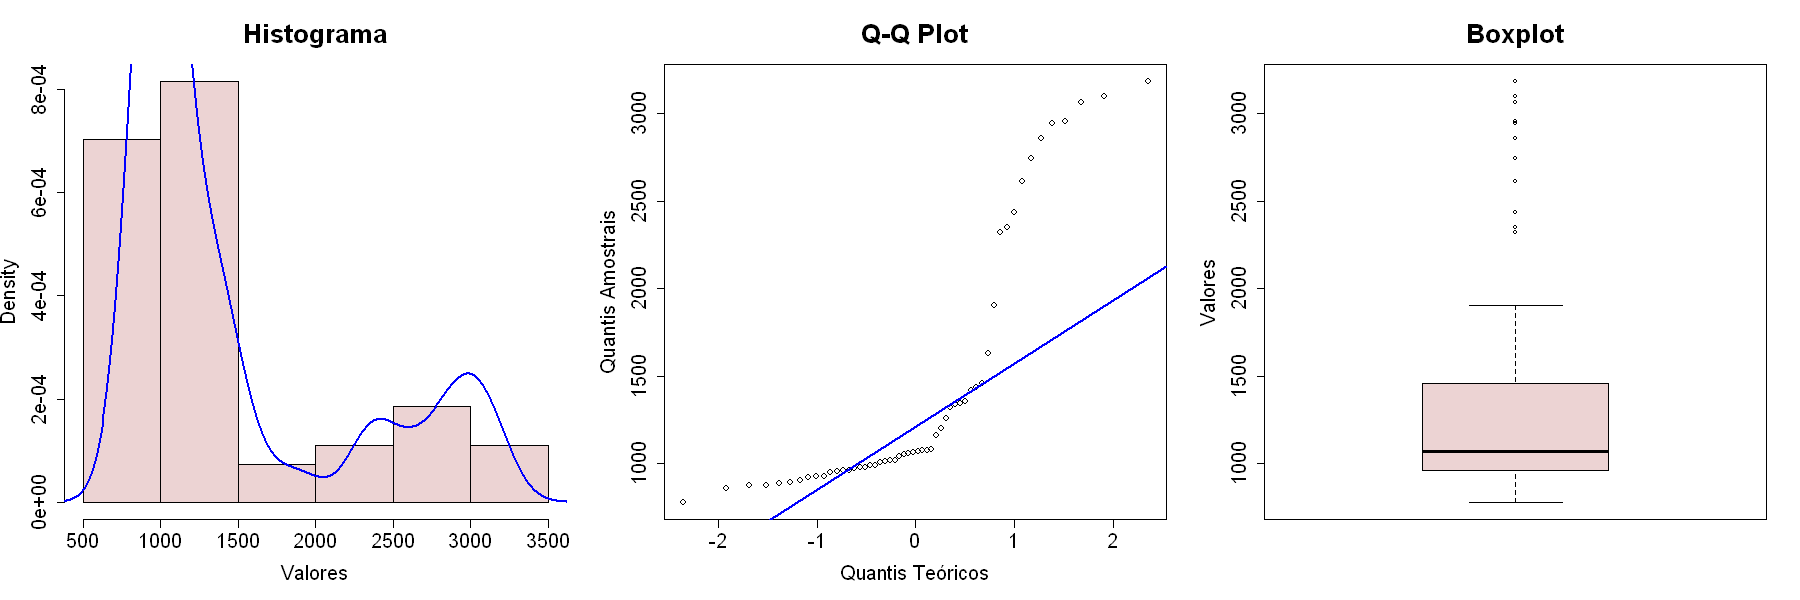

In [14]:
# Executando em: df10$valor
cat("===================================\n")
cat('Teste Normalidade - df10$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df10$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df11$valor:
Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 4.166711e-08 

=> Os dados NÃO seguem uma distribuição normal (p <= 0.05).
Recomendação: Considere usar testes não paramétricos (ex: Wilcoxon, Kruskal-Wallis) ou transformar os dados.


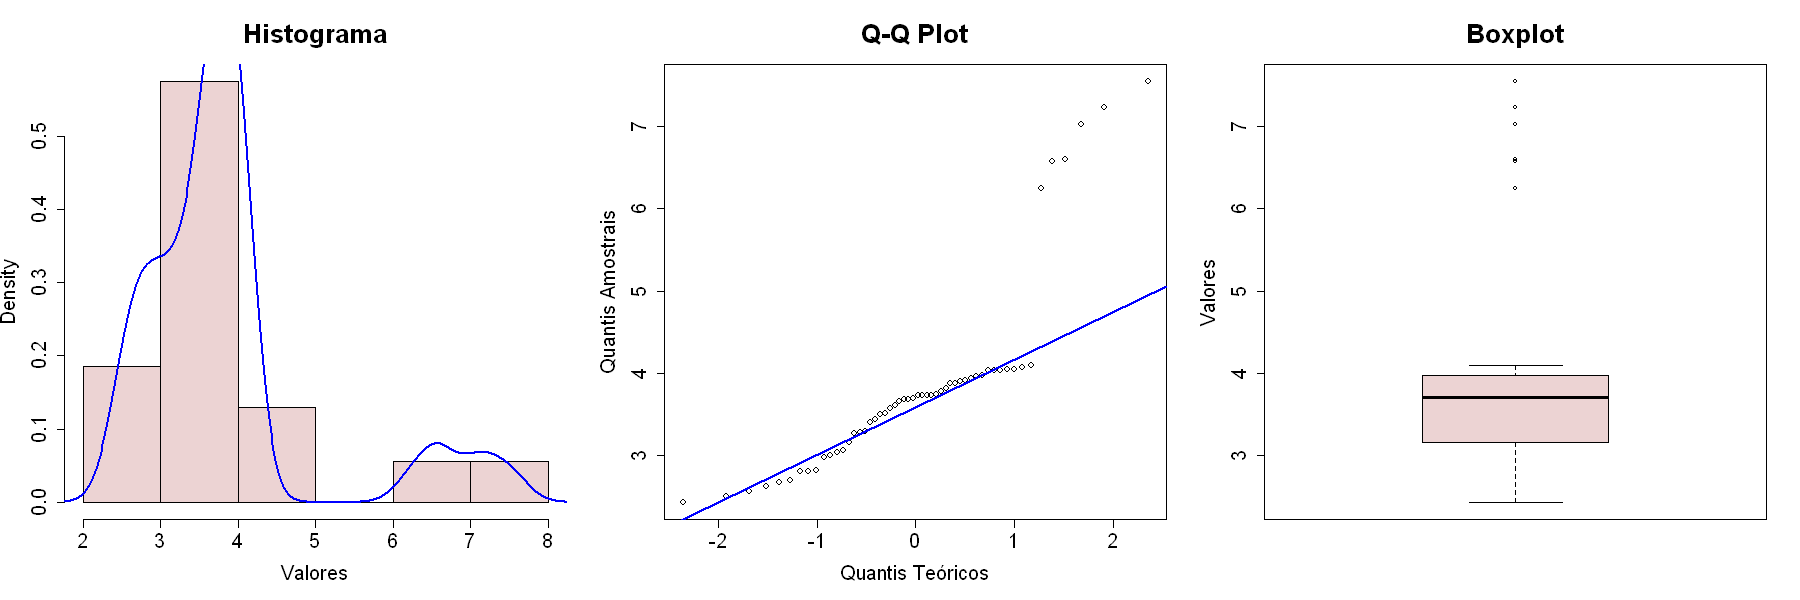

In [15]:
# Executando em: df11$valor
cat("===================================\n")
cat('Teste Normalidade - df11$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df11$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

Teste Normalidade - df12$valor:
Resultados do teste de Shapiro-Wilk (n = 54 ):
p-value = 0.05986566 

=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


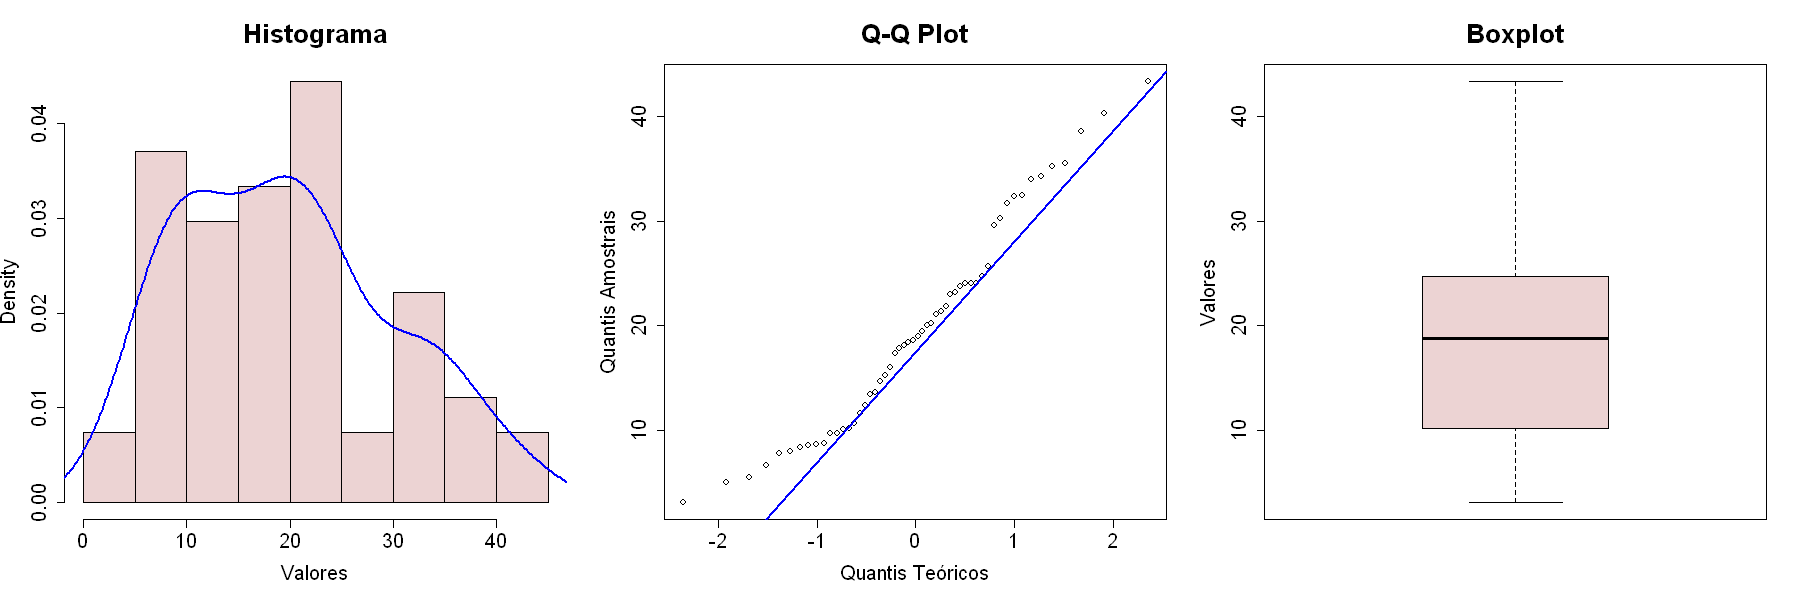

In [16]:
# Executando em: df12$valor
cat("===================================\n")
cat('Teste Normalidade - df12$valor:\n')
cat("===================================\n")
teste_normalidade_completo(df12$valor, cor_grafico = "#ecd3d3", cor_linha = "blue")

In [17]:
# Vetor com os p-valores já obtidos (baseado no meu notebook)
p_valores <- c(
  longevidade1 = 0.8527675,
  longevidade2 = 0.7708141,
  longevidade3 = 0.6585880,
  longevidade4 = 0.01319688,  # NÃO normal
  escolaridade1 = 0.09854821,
  escolaridade2 = 0.6911499,
  escolaridade3 = 0.2575266,
  escolaridade4 = 0.2304887,
  economia1 = 0.8527675,
  economia2 = 4.913598e-11,   # NÃO normal (idêntica a economia1?)
  consumo1 = 4.166711e-08,    # NÃO normal
  consumo2 = 0.05986566
)

normalidade <- data.frame(
  Variavel = names(p_valores),
  p_valor = p_valores,
  Normal = ifelse(p_valores > 0.05, "Sim", "Não")
)
print(normalidade)

cat("\nVariáveis que NÃO seguem distribuição normal:",
    paste(normalidade$Variavel[normalidade$Normal == "Não"], collapse = ", "))

                   Variavel      p_valor Normal
longevidade1   longevidade1 8.527675e-01    Sim
longevidade2   longevidade2 7.708141e-01    Sim
longevidade3   longevidade3 6.585880e-01    Sim
longevidade4   longevidade4 1.319688e-02    Não
escolaridade1 escolaridade1 9.854821e-02    Sim
escolaridade2 escolaridade2 6.911499e-01    Sim
escolaridade3 escolaridade3 2.575266e-01    Sim
escolaridade4 escolaridade4 2.304887e-01    Sim
economia1         economia1 8.527675e-01    Sim
economia2         economia2 4.913598e-11    Não
consumo1           consumo1 4.166711e-08    Não
consumo2           consumo2 5.986566e-02    Sim

Variáveis que NÃO seguem distribuição normal: longevidade4, economia2, consumo1

### **3.2. Histogramas com KDE e Curva Normal (Grade 4x3)**

Cada gráfico mostra:
- Histograma (barras cinza)
- Curva KDE (vermelha tracejada) – forma real dos dados
- Curva Normal teórica (azul) – ajustada pela média e desvio da variável

**Interpretação visual:** Se as curvas vermelha e azul estiverem próximas, a variável é aproximadamente normal (confirma o teste). Se estiverem distantes, há assimetria ou caudas pesadas.

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


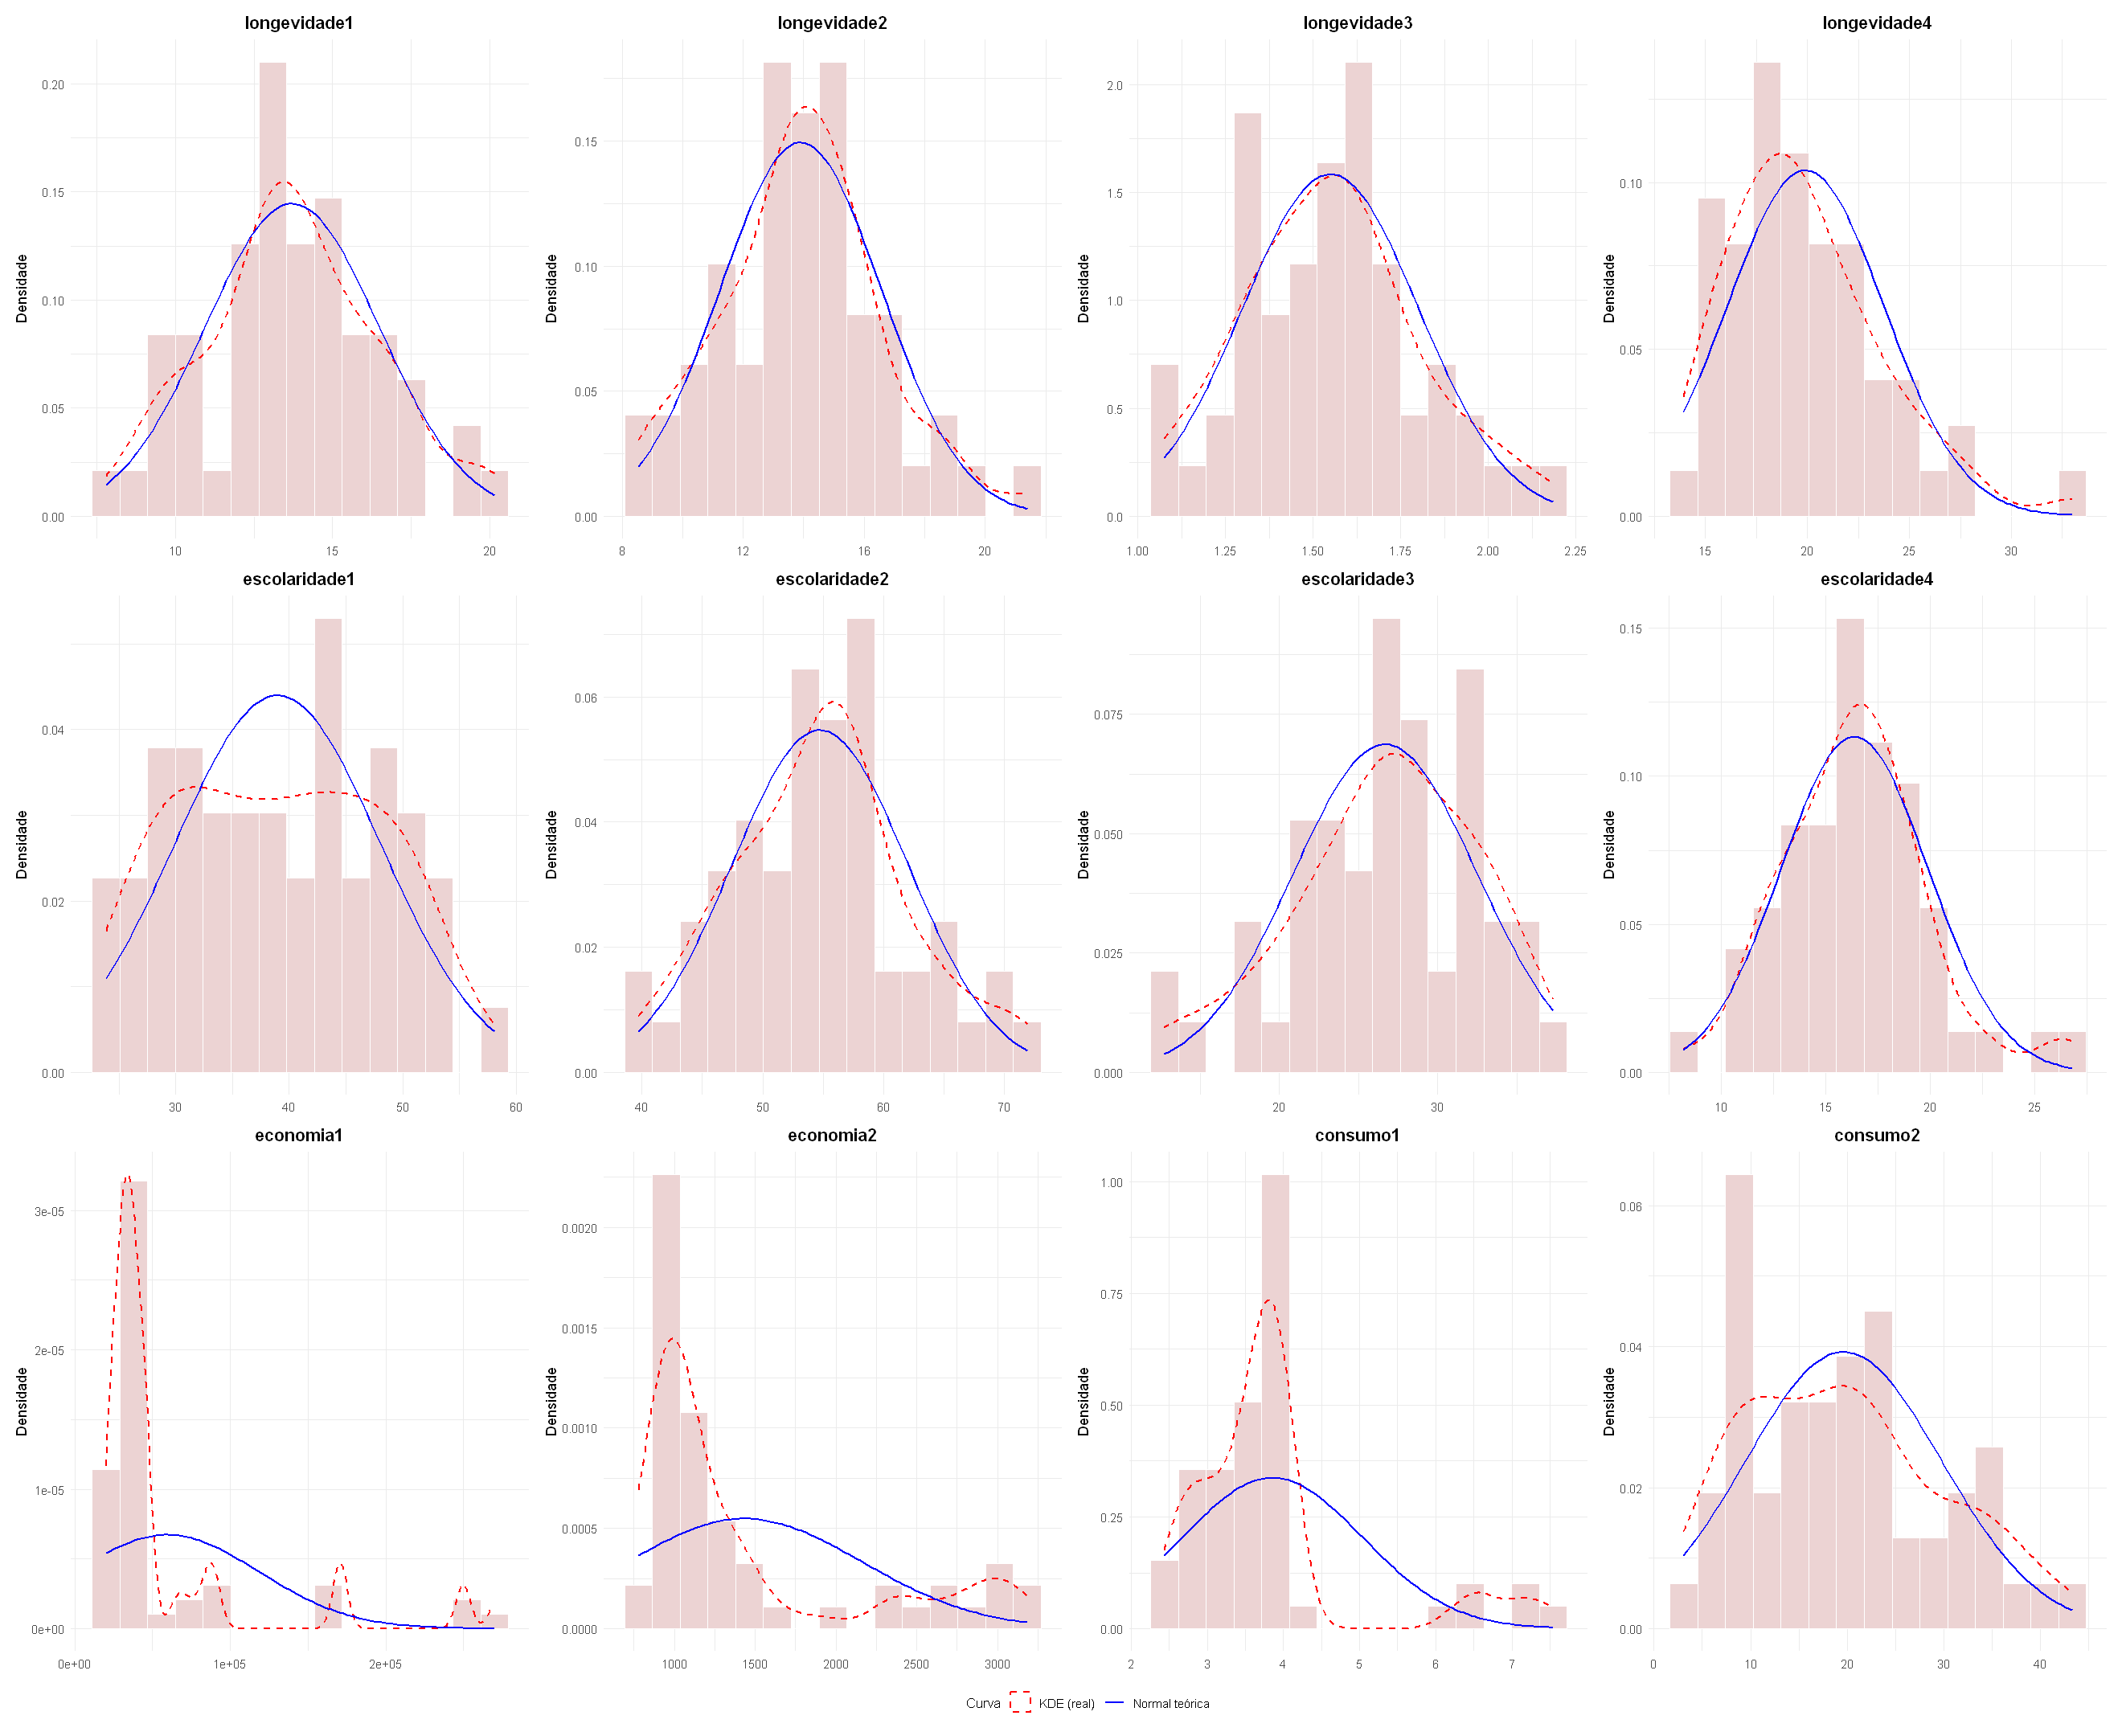

In [18]:
# Lista de gráficos
lista_hist <- list()

for (i in 1:ncol(dados)) {
  nome <- names(dados)[i]
  x <- dados[[i]]
  mu <- mean(x, na.rm = TRUE)
  sigma <- sd(x, na.rm = TRUE)
  
  p <- ggplot(dados, aes(x = .data[[nome]])) +
    geom_histogram(aes(y = after_stat(density)), 
                   bins = 15, fill = "#ecd3d3", color = "white") +
    geom_density(aes(y = after_stat(density), color = "KDE (real)"), 
                 size = 0.8, linetype = 2) +
    stat_function(fun = dnorm, 
                  args = list(mean = mu, sd = sigma),
                  aes(color = "Normal teórica"),
                  size = 0.8) +
    scale_color_manual(name = "Curva", 
                       values = c("KDE (real)" = "red", 
                                  "Normal teórica" = "blue")) +
    labs(title = nome, x = NULL, y = "Densidade") +
    theme_minimal(base_size = 11) +
    theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 13),
          legend.position = "bottom",
          legend.title = element_text(size = 10),
          legend.text = element_text(size = 9))
  
  lista_hist[[i]] <- p
}

# Ajuste de tamanho
options(repr.plot.width = 22, repr.plot.height = 18)

# Exibir com legenda coletada
wrap_plots(lista_hist, ncol = 4, guides = "collect") & 
  theme(legend.position = "bottom")

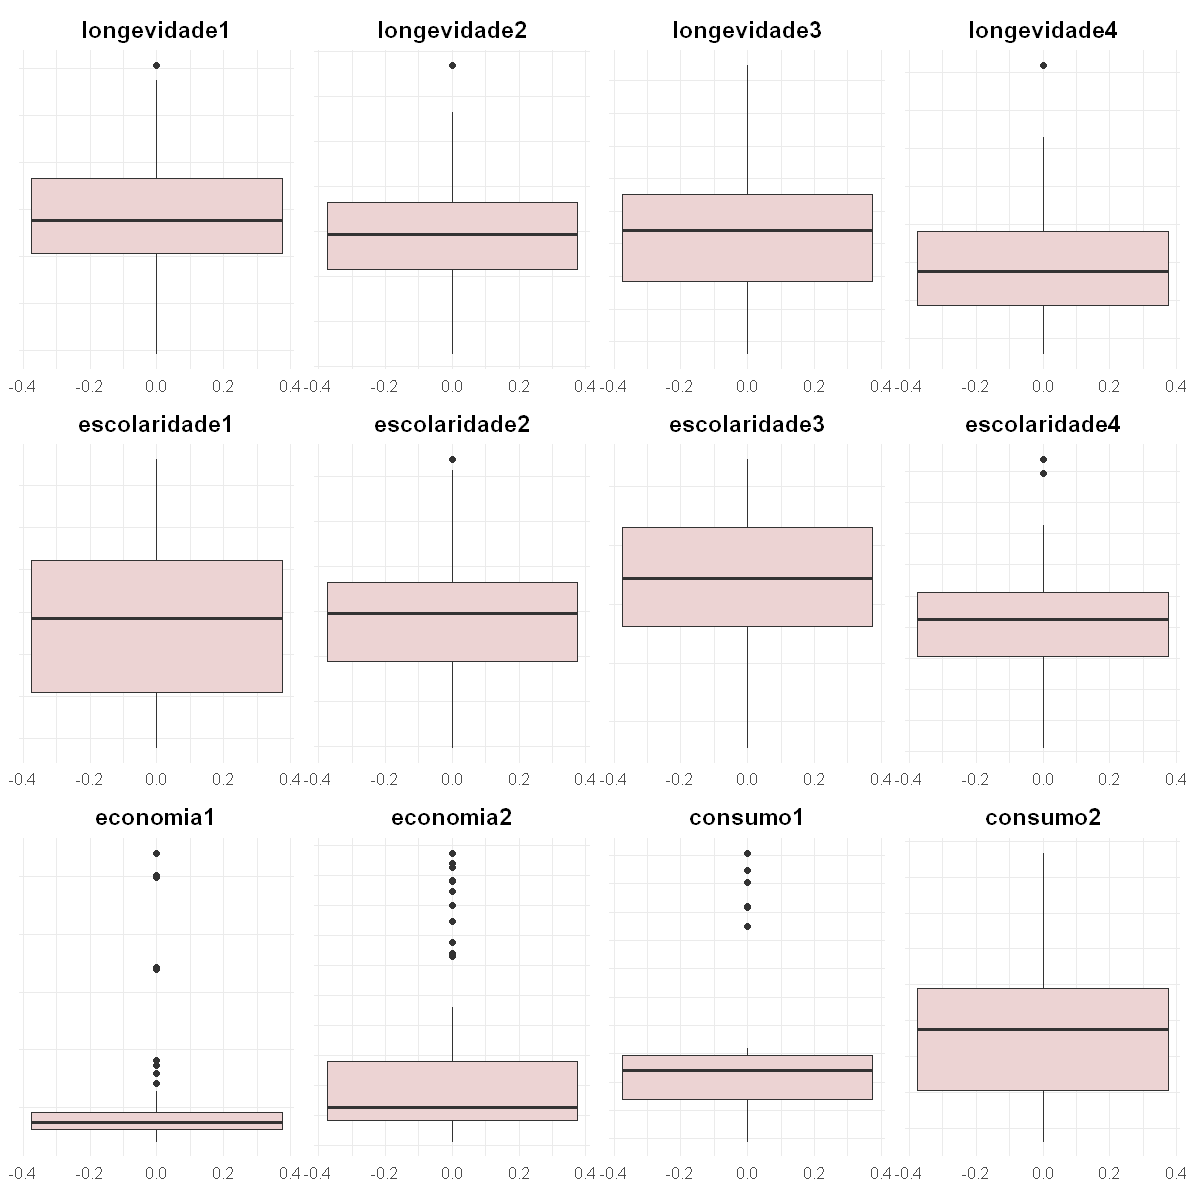

In [19]:
# Boxplots em grade para todas as variáveis (visão de outliers e quartis)

lista_box <- list()
for (i in 1:ncol(dados)) {
  nome <- names(dados)[i]
  p <- ggplot(dados, aes(y = .data[[nome]])) +
    geom_boxplot(fill = "#ecd3d3", color = "#333333") +
    labs(title = nome, x = NULL, y = NULL) +
    theme_minimal(base_size = 12) +
    theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
          axis.text.y = element_blank())
  lista_box[[i]] <- p
}

options(repr.plot.width = 10, repr.plot.height = 10)
wrap_plots(lista_box, ncol = 4)

### **4. Análise Exploratória - Bivariada (Correlação)**

Agora examinamos as relações entre todas as variáveis para identificar quais são candidatas a preditoras na regressão.

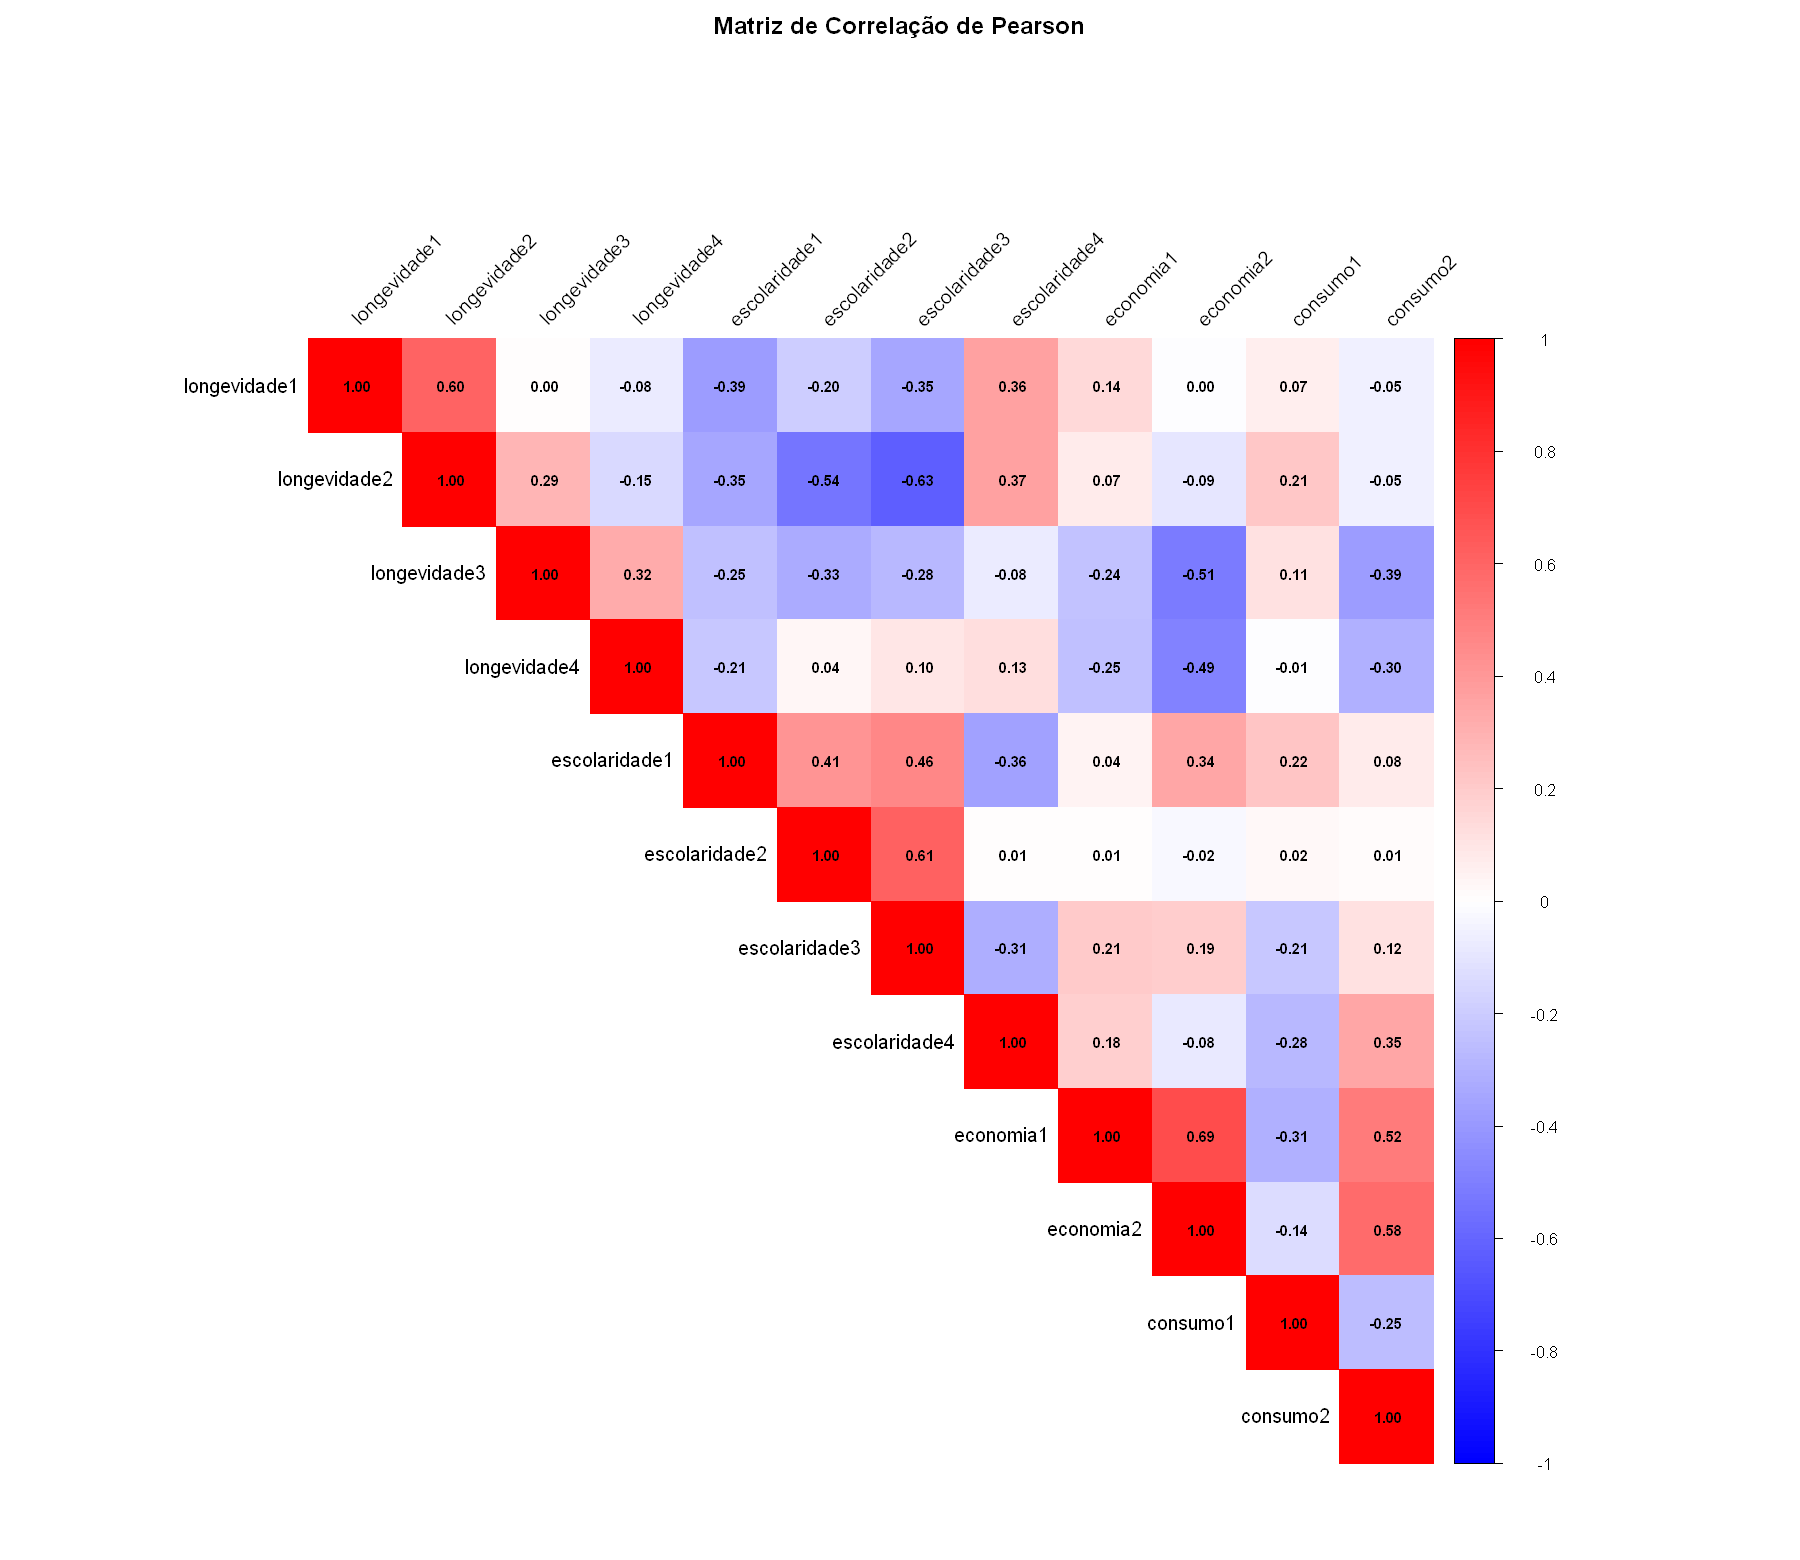

In [20]:
# Matriz de correlação de Pearson
cor_pearson <- cor(dados, use = "complete.obs")

# Visualização com números
options(repr.plot.width = 15, repr.plot.height = 13)
corrplot(cor_pearson, 
         method = "color",
         type = "upper",
         tl.col = "black",
         tl.srt = 45,
         addCoef.col = "black",   # mostra os números
         number.cex = 0.75,
         col = colorRampPalette(c("blue", "white", "red"))(200),
         title = "Matriz de Correlação de Pearson",
         mar = c(0,0,2,0))

### **4.1. Interpretação da Matriz de Correlação**

**Principais destaques:**
- `economia1` e `economia2` têm correlação **1.00** → são variáveis idênticas (duplicadas). **Uma delas deve ser descartada.**
- `economia1` tem correlação moderada com `consumo2` (0.52) → o consumo é o melhor preditor para a economia.
- `economia1` tem correlação negativa com `longevidade4` (-0.25) e `longevidade3` (-0.24) → sugerindo que maior mortalidade (pior longevidade) está associada a menor economia.
- `economia1` tem correlação fraca com escolaridade (máx 0.21) → educação não parece ser um forte preditor direto da economia neste dataset.
- As variáveis de longevidade e escolaridade têm correlações moderadas entre si (ex: longevidade2 × escolaridade3 = -0.63).

### **4.2. Matriz de Dispersão (Scatterplot Matrix)**

Os gráficos de dispersão confirmam visualmente as relações observadas na matriz numérica.

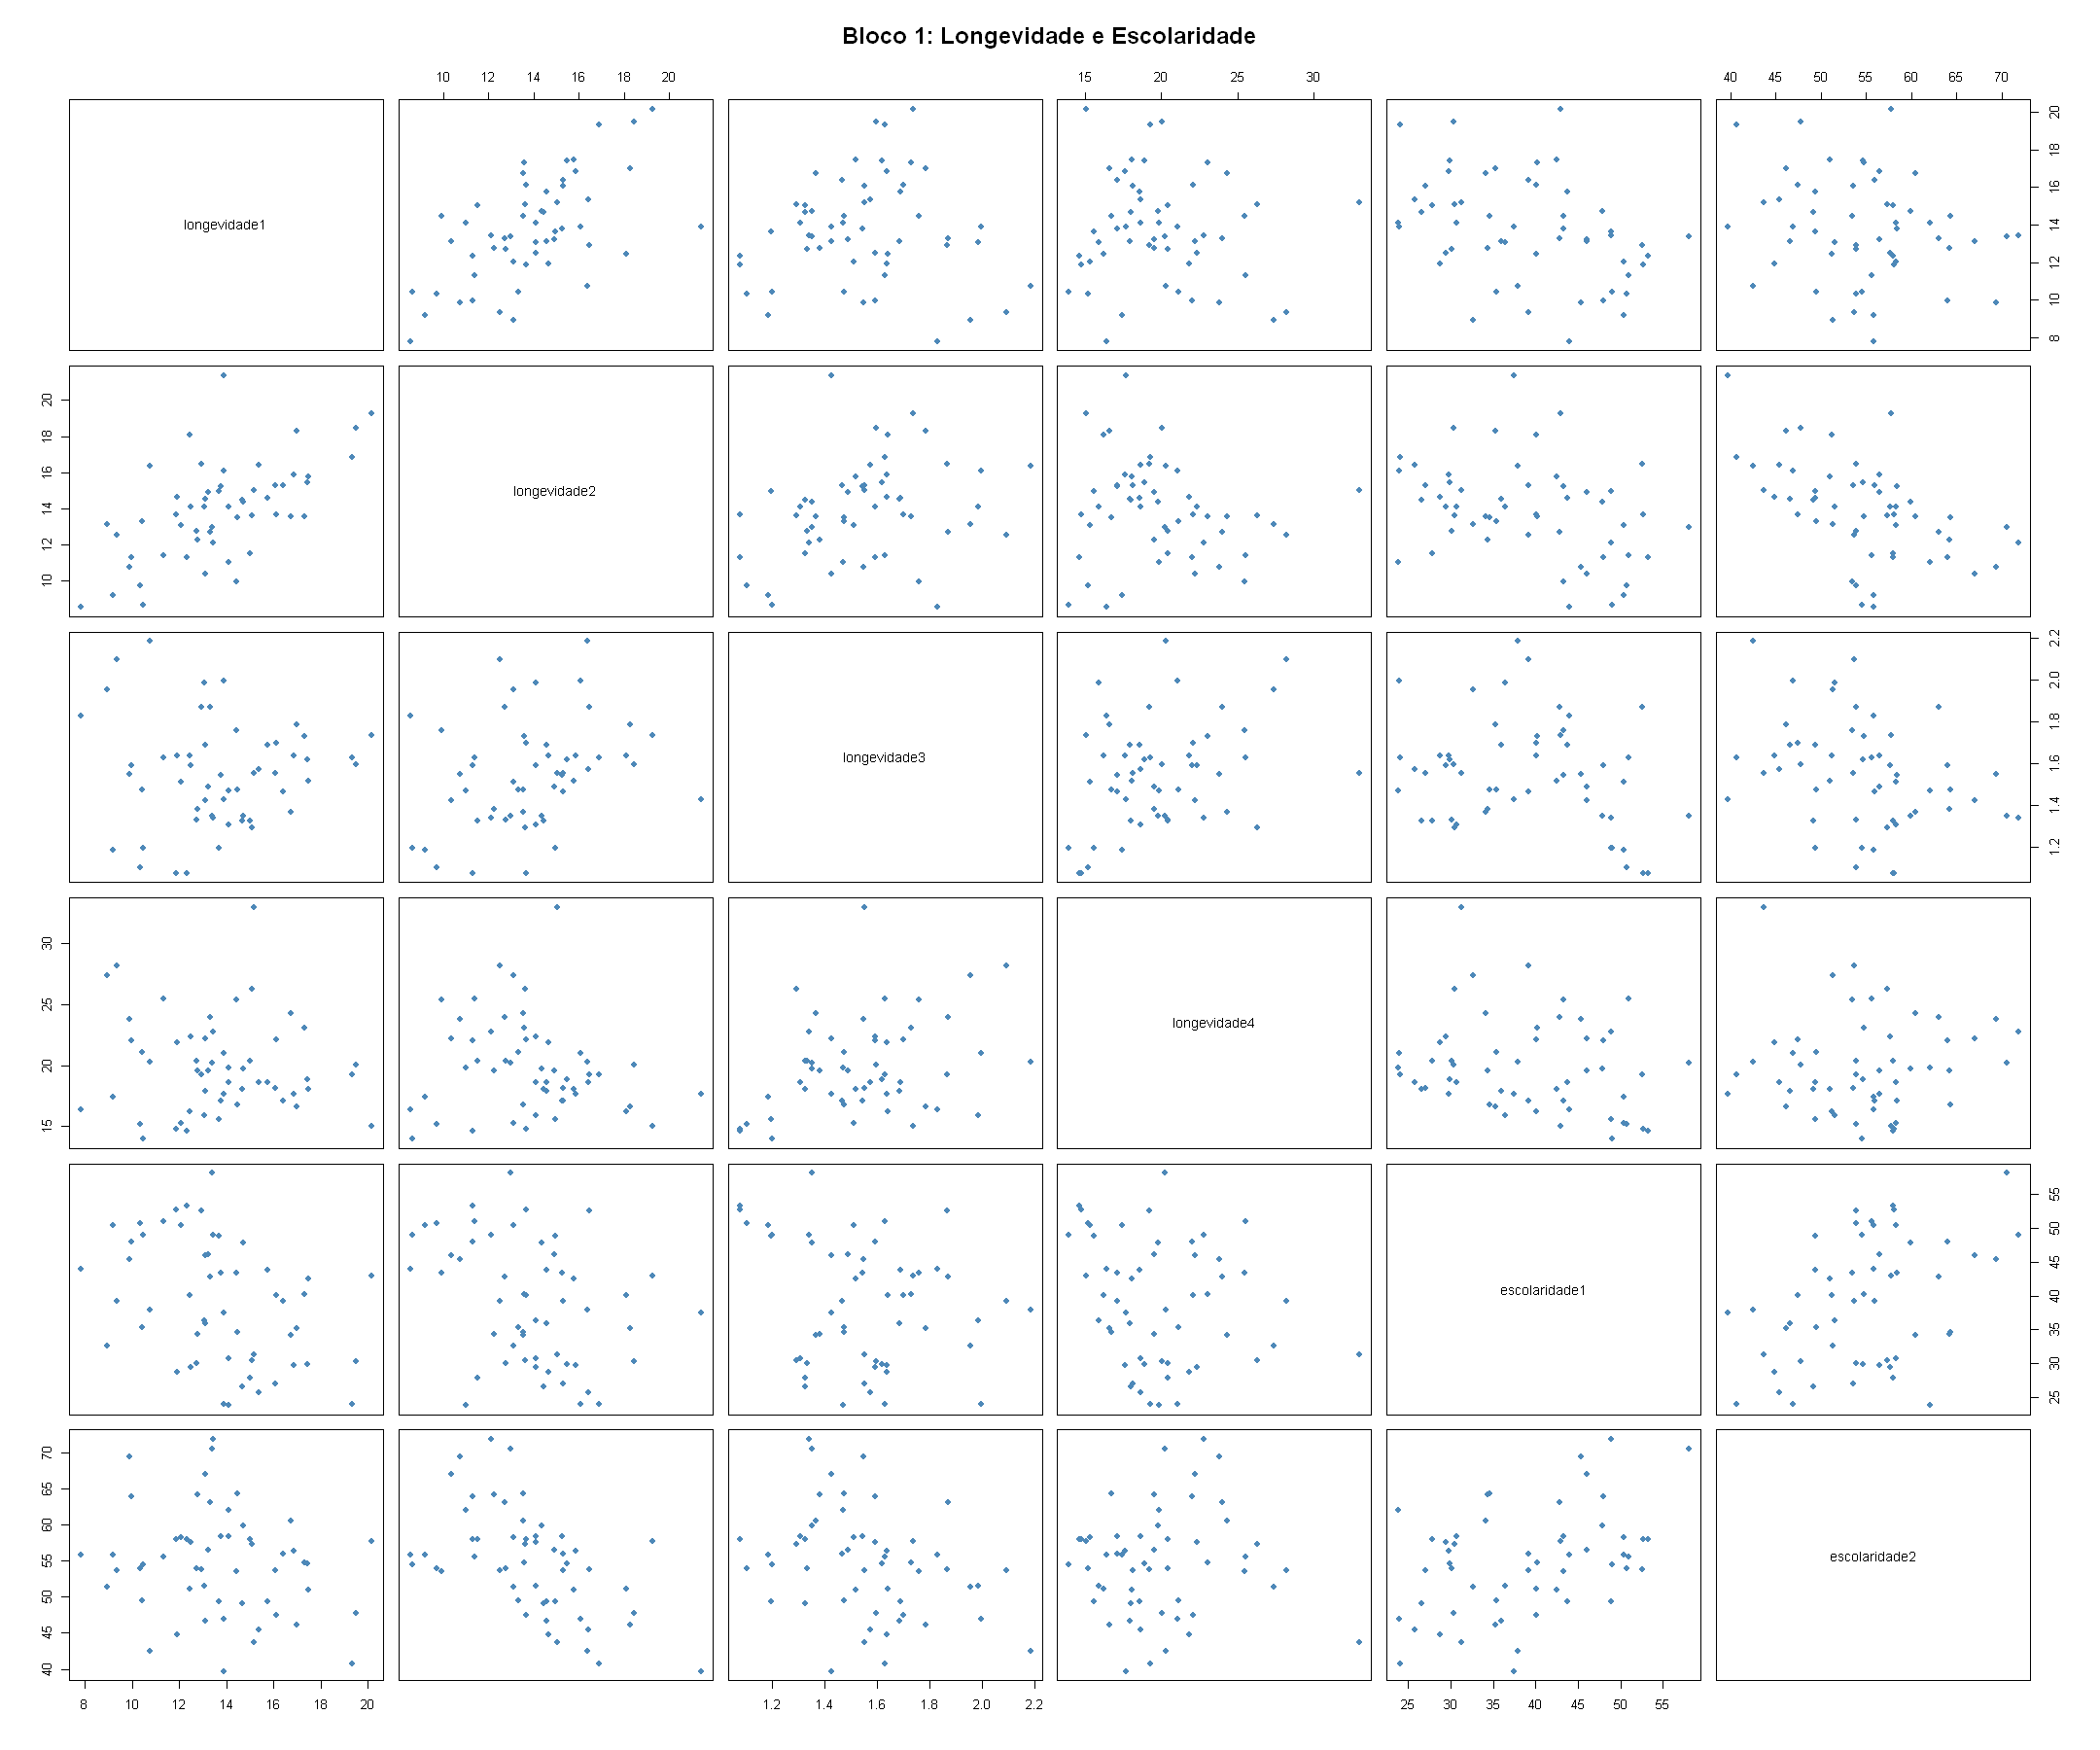

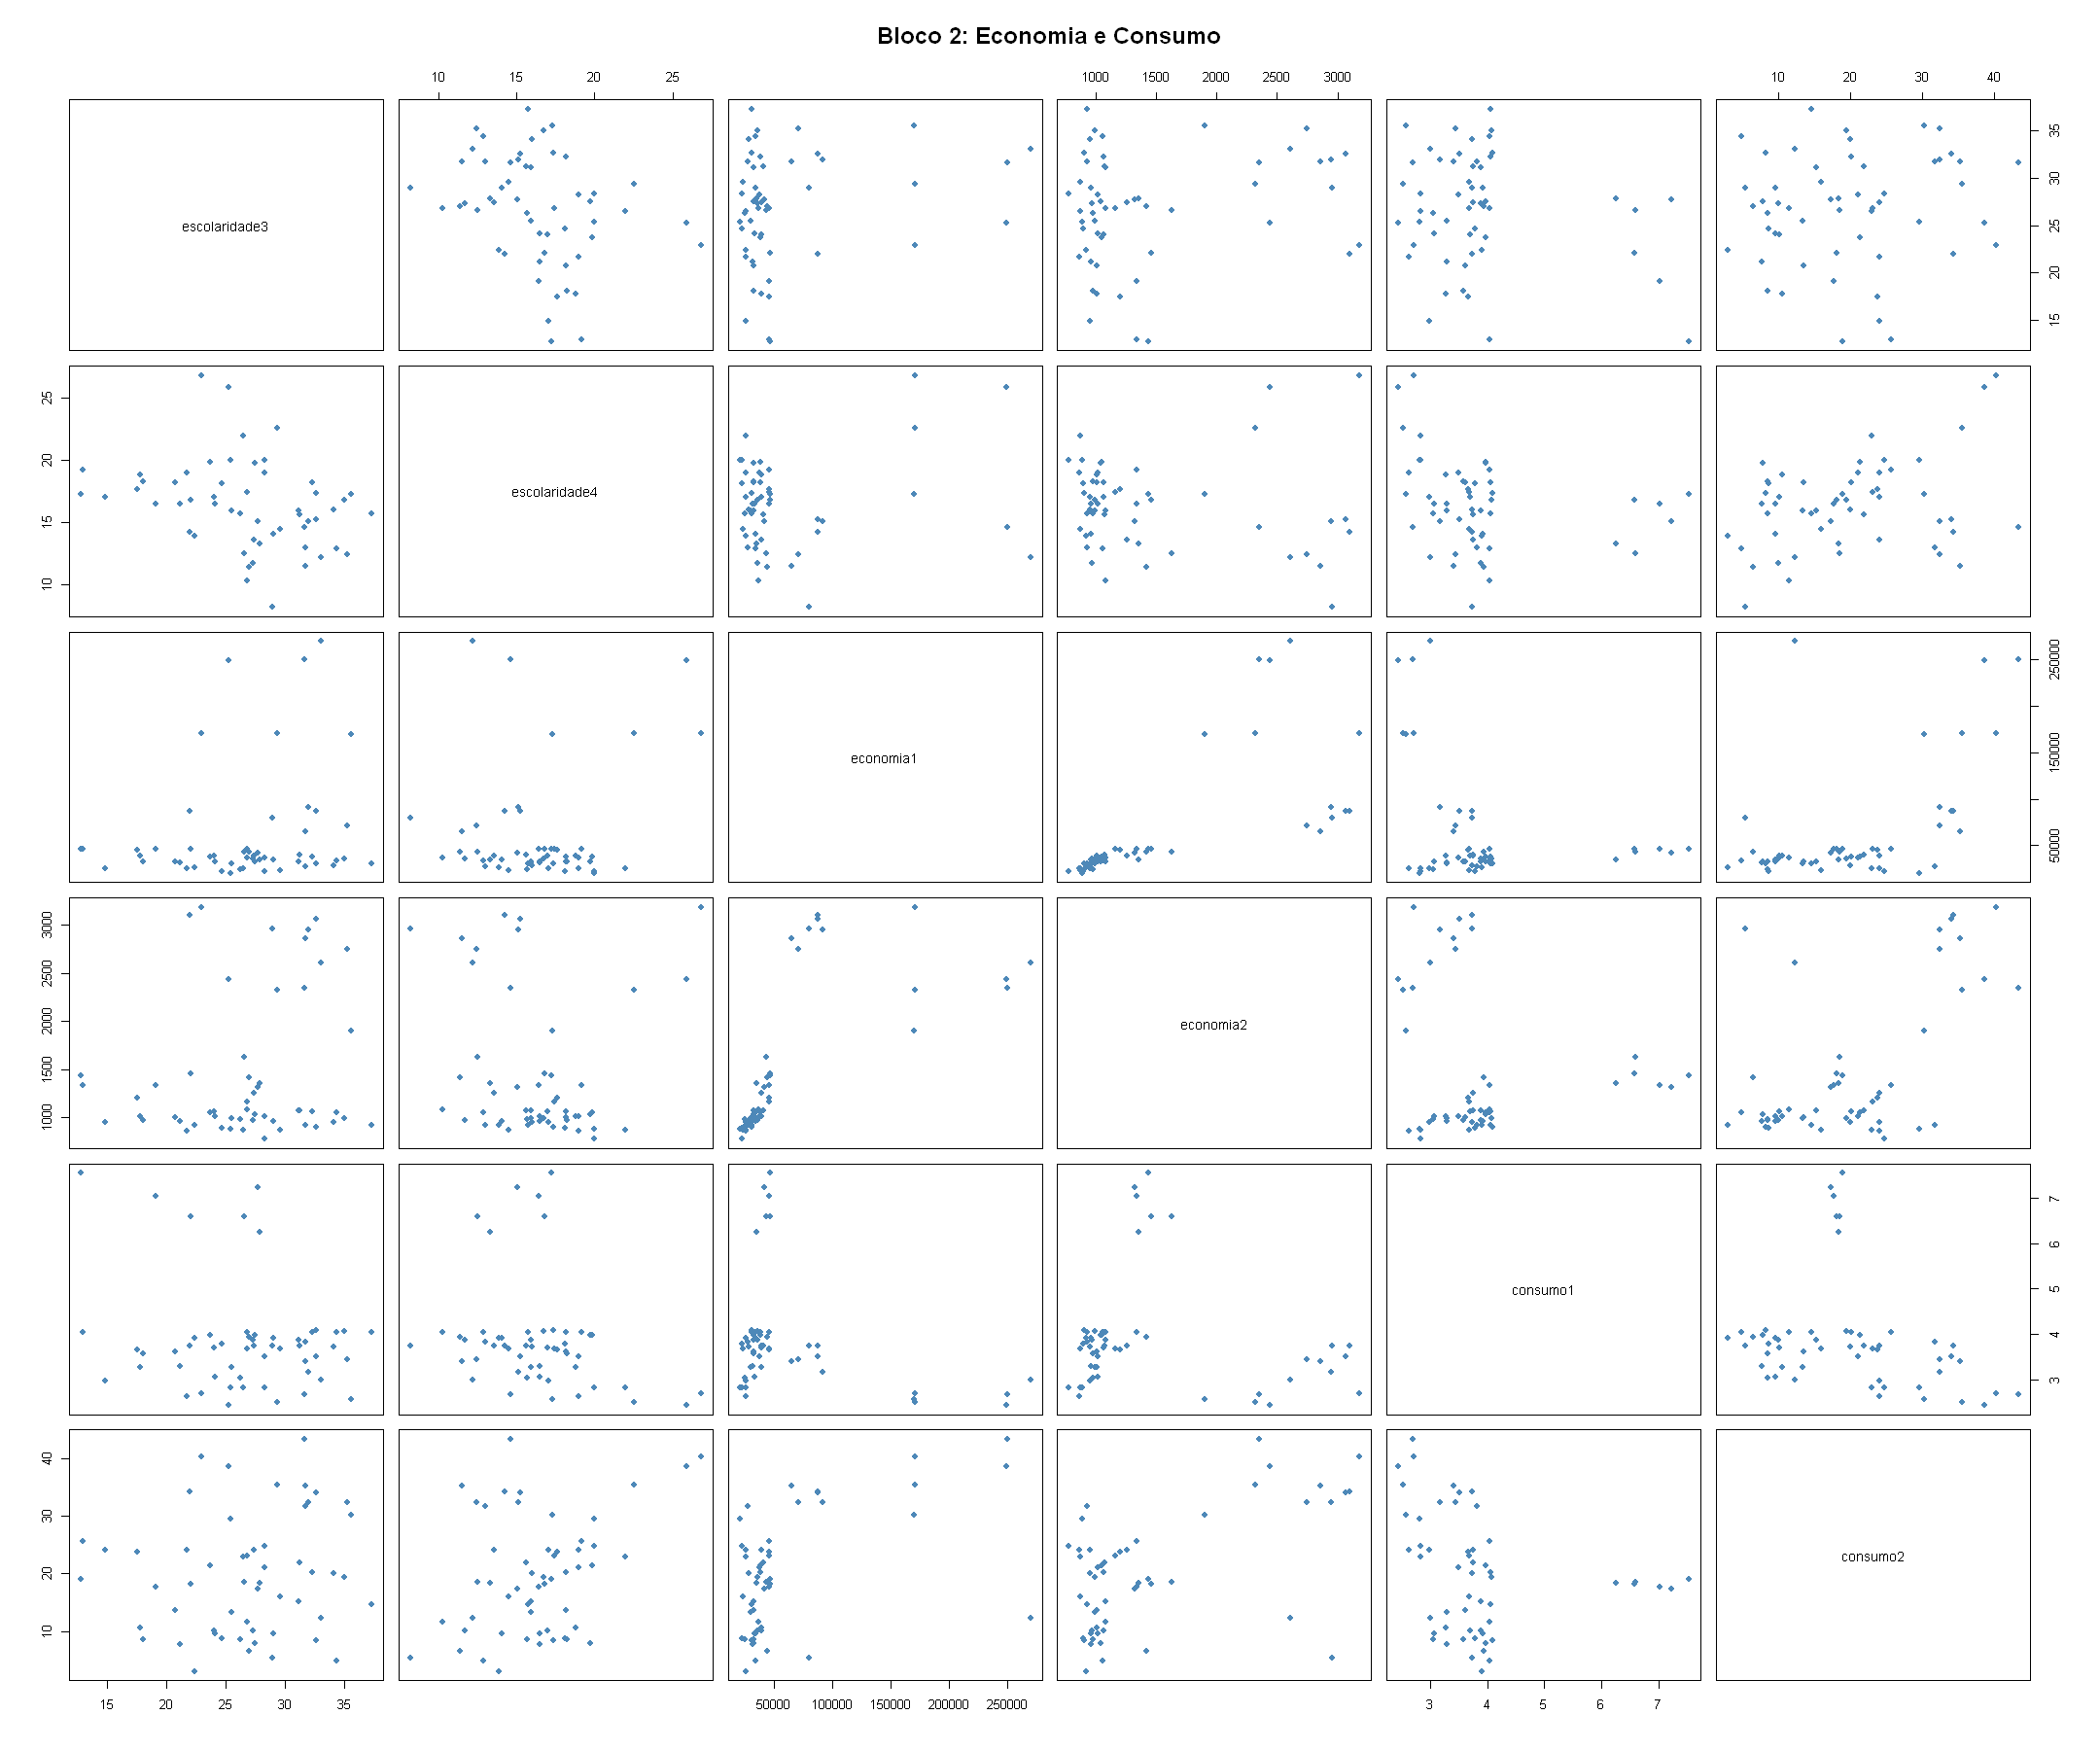

In [21]:
# Para não poluir, dividimos em dois blocos de 6
options(repr.plot.width = 18, repr.plot.height = 15)

pairs(dados[, 1:6], pch = 19, col = "#4d88b8", 
      main = "Bloco 1: Longevidade e Escolaridade")

pairs(dados[, 7:12], pch = 19, col = "#4d88b8", 
      main = "Bloco 2: Economia e Consumo")

## **5. Regressão Linear**

Com base na EDA, escolhemos:
- **Variável resposta (Y):** `economia1` (atividade econômica / renda)
- **Principal preditor (X):** `consumo2` (melhor correlação com Y: 0.52)

Testaremos um modelo simples e um modelo múltiplo adicionando `longevidade4` (correlação -0.25).

In [22]:
# Preparar dataframe específico para regressão
dados_reg <- data.frame(
  economia = dados$economia1,      # Y
  consumo = dados$consumo2,        # X1
  longevidade = dados$longevidade4 # X2
)

# Verificar NAs
colSums(is.na(dados_reg))

economia     consumo longevidade 
          0           0           0

### **5.1. Regressão Simples: `economia ~ consumo`**

In [23]:
mod_simples <- lm(economia ~ consumo, data = dados_reg)
summary(mod_simples)


Call:
lm(formula = economia ~ consumo, data = dados_reg)

Residuals:
   Min     1Q Median     3Q    Max 
-69382 -26007 -10570   6710 232947 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -296.0    15249.6  -0.019    0.985    
consumo       3032.1      691.1   4.388 5.62e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 51120 on 52 degrees of freedom
Multiple R-squared:  0.2702,	Adjusted R-squared:  0.2562 
F-statistic: 19.25 on 1 and 52 DF,  p-value: 5.621e-05


**Interpretação:**

- **Coeficiente do consumo (β₁) = 3032.1** → para cada aumento de 1 unidade no consumo, a economia aumenta em média 3032.1 unidades. O p-valor é altamente significativo (5.62e-05).
- **R² = 0.2702** → o modelo explica cerca de 27% da variabilidade da economia. Não é alto, mas é razoável para dados socioeconômicos regionais.
- **Intercepto** não é significativo (p = 0.985) → pode ser interpretado como esperado, pois não há observações com consumo zero.

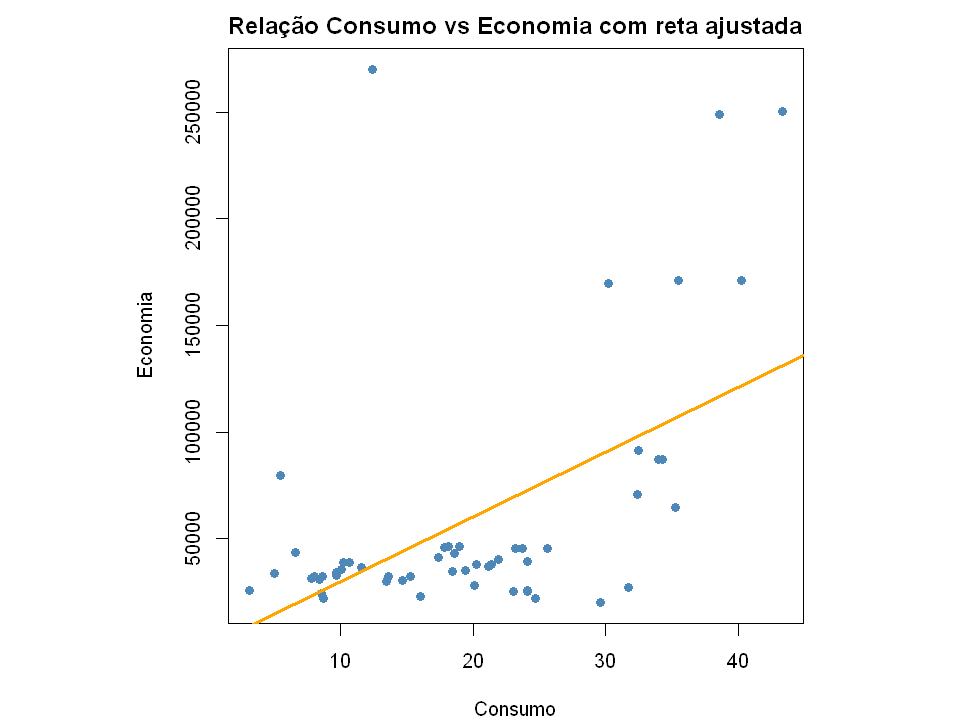

In [24]:
# Gráfico da reta ajustada
options(repr.plot.width = 8, repr.plot.height = 6)
par(pty = "s", mar = c(4,4,2,1))
plot(dados_reg$consumo, dados_reg$economia,
     pch = 19, col = "#4d88b8",
     xlab = "Consumo", ylab = "Economia",
     main = "Relação Consumo vs Economia com reta ajustada")
abline(mod_simples, col = "orange", lwd = 3)

### **5.2. Regressão Múltipla: `economia ~ consumo + longevidade`**

In [25]:
mod_multiplo <- lm(economia ~ consumo + longevidade, data = dados_reg)
summary(mod_multiplo)


Call:
lm(formula = economia ~ consumo + longevidade, data = dados_reg)

Residuals:
   Min     1Q Median     3Q    Max 
-71711 -26873 -11588   9035 228801 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  34339.2    45195.1   0.760 0.450873    
consumo       2853.0      727.3   3.923 0.000263 ***
longevidade  -1563.3     1919.5  -0.814 0.419185    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 51290 on 51 degrees of freedom
Multiple R-squared:  0.2796,	Adjusted R-squared:  0.2513 
F-statistic: 9.895 on 2 and 51 DF,  p-value: 0.0002337


**Comparação entre modelos:**

| Métrica | Simples | Múltiplo |
| :--- | :--- | :--- |
| R² | 0.2702 | 0.2796 |
| R² ajustado | 0.2562 | 0.2513 |
| Erro residual | 51120 | 51290 |
| Preditores significativos | consumo | consumo apenas (longevidade p=0.419) |

**Conclusão:** a adição de `longevidade` **não melhora o modelo** — o R² ajustado diminui e o preditor não é significativo. Portanto, o **modelo simples (`economia ~ consumo`) é preferível**. É mais parcimonioso e igualmente explicativo.

### **5.3. Diagnóstico de Resíduos (Modelo Simples)**

O gráfico de resíduos vs ajustados é essencial para verificar as suposições de linearidade e homocedasticidade.

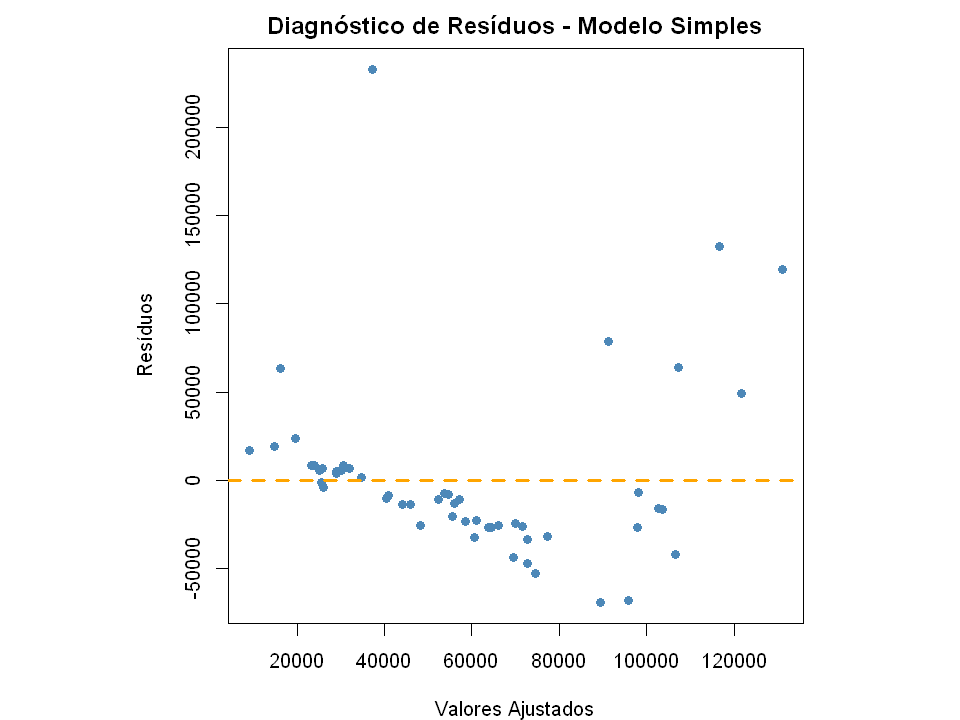

In [26]:
par(pty = "s", mar = c(4,4,2,1))
plot(fitted(mod_simples), resid(mod_simples),
     pch = 19, col = "#4d88b8",
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Diagnóstico de Resíduos - Modelo Simples")
abline(h = 0, col = "orange", lwd = 3, lty = 2)

**Análise do gráfico de resíduos:**

- Os resíduos estão dispersos aleatoriamente em torno da linha zero, sem um padrão claro de curva ou funil.
- Há alguns pontos mais extremos (resíduos positivos grandes), mas não configuram um padrão sistemático.
- Isso sugere que a relação linear é razoável e a variância é aproximadamente constante (homocedasticidade).
- O modelo simples atende, de forma aceitável, às suposições da regressão linear.

### **6. Conclusão Final**

- **Variável resposta escolhida:** `economia1` (indicador de atividade econômica).
- **Melhor modelo:** regressão linear simples com `consumo2` como preditor.
- **Equação final:**

$$
\text{economia} = -296.0 + 3032.1 \times \text{consumo}
$$

- **Interpretação:** a cada 1 unidade de aumento no consumo, a economia aumenta, em média, 3032.1 unidades.
- **R² = 0.2702** → 27% da variância da economia é explicada pelo consumo.
- **Diagnóstico:** resíduos sem padrão, validando as suposições do modelo.
- **Variáveis descartadas:** `longevidade4` não se mostrou significativa; `economia2` foi removida por ser idêntica a `economia1` (multicolinearidade perfeita).

Este modelo fornece uma base inicial para entender os determinantes da economia nos municípios, com potencial para ser melhorado com a inclusão de outras variáveis ou transformações em análises futuras.

---
*Notebook gerado automaticamente como parte da disciplina Teoria do Aprendizado Estatístico — Fatec Rubens Lara.*